<h1>Alphafold 2 Protein Structure Prediction</h1>
sub-module to the Remote Homolog Alignment ML Project

> This colab notebook is used to run Alphafold 2 using MMSeqs2 to predict the structure of a given protein sequence

Reference Notebook : [Colab](https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/AlphaFold2.ipynb) ~ Martin Steinegger and Sergey Ovchinnikov

# Blitz Run and Inference
Below code cell loads the model in `AlphaFoldRun()` class and make its ready for use.

- To run your given sequence
```
af2 = AlphaFoldRun(sequence:str,job_name:str)
af2.main() #output folder generated in root dir
```
> Eg. (sequence="HVKKGD", job_name="uL24_SH3")

For more parameters and usage flexibility refer to following code cells

In [ ]:
# @title
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

class AlphaFoldRun:
  def __init__(self,seq,jobname,num_relax_val=0,template_mode="none",msa_mode = "mmseqs2_uniref_env",
               pair_mode = "unpaired_paired",model_type = "auto",num_recycles = "3",recycle_early_stop_tolerance = "auto",
               relax_max_iterations = 200,pairing_strategy = "greedy",calc_extra_ptm = False,max_msa = "auto",num_seeds = 1,
               use_dropout = False, drive=None, save_to_google_drive=False, dpi=200):
    self.dependencies_loaded = False
    self.prediction_dependenices_loaded = False
    self.seq = seq
    self.jobname = jobname
    self.num_relax = num_relax_val
    self.template_mode = template_mode
    self.use_amber = num_relax_val > 0
    self.msa_mode = msa_mode
    self.pair_mode = pair_mode
    self.model_type = model_type
    self.num_recycles = num_recycles
    self.recycle_early_stop_tolerance = recycle_early_stop_tolerance
    self.relax_max_iterations = relax_max_iterations
    self.pairing_strategy = pairing_strategy
    self.calc_extra_ptm = calc_extra_ptm
    self.max_msa = max_msa
    self.num_seeds = num_seeds
    self.use_dropout = use_dropout
    self.queries_path = None
    self.custom_template_path = None
    self.use_templates = False
    self.save_all = False
    self.save_recycles = False
    self.drive = drive
    self.dpi = dpi
    self.save_to_google_drive = save_to_google_drive

  def add_hash(self,x,y):
    return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

  def input_seq(self):
    # remove whitespaces
    self.seq = "".join(self.seq.split())

    basejobname = "".join(self.jobname.split())
    basejobname = re.sub(r'\W+', '', basejobname)
    self.jobname = self.add_hash(basejobname, self.seq)

    # check if directory with jobname exists
    def check(folder):
      if os.path.exists(folder):
        return False
      else:
        return True
    if not check(self.jobname):
      n = 0
      while not check(f"{self.jobname}_{n}"): n += 1
      self.jobname = f"{self.jobname}_{n}"

    # make directory to save results
    os.makedirs(self.jobname, exist_ok=True)

    # save queries
    self.queries_path = os.path.join(self.jobname, f"{self.jobname}.csv")
    with open(self.queries_path, "w") as text_file:
      text_file.write(f"id,sequence\n{self.jobname},{self.seq}")

    if self.template_mode == "pdb100":
      self.use_templates = True
      self.custom_template_path = None
    elif self.template_mode == "custom":
      self.custom_template_path = os.path.join(self.jobname,f"template")
      os.makedirs(self.custom_template_path, exist_ok=True)
      uploaded = files.upload()
      self.use_templates = True
      for fn in uploaded.keys():
        os.rename(fn,os.path.join(self.custom_template_path,fn))
    else:
      self.custom_template_path = None
      self.use_templates = False

    print("jobname",self.jobname)
    print("sequence",self.seq)
    print("length",len(self.seq.replace(":","")))

  def dependencies(self):
    # %%time
    import os
    USE_AMBER = self.use_amber
    USE_TEMPLATES = self.use_templates
    PYTHON_VERSION = python_version

    if not os.path.isfile("COLABFOLD_READY"):
      print("installing colabfold...")
      os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
      if os.environ.get('TPU_NAME', False) != False:
        os.system("pip uninstall -y jax jaxlib")
        os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
      os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
      os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
      # hack to fix TF crash
      os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so /usr/local/lib/python3.*/dist-packages/tensorflow/lite/python/*/*.so")
      os.system("touch COLABFOLD_READY")

    if USE_AMBER or USE_TEMPLATES:
      if not os.path.isfile("CONDA_READY"):
        print("installing conda...")
        os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
        os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
        os.system("mamba config --set auto_update_conda false")
        os.system("touch CONDA_READY")

    if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
      print("installing hhsuite and amber...")
      os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
      os.system("touch HH_READY")
      os.system("touch AMBER_READY")
    else:
      if USE_TEMPLATES and not os.path.isfile("HH_READY"):
        print("installing hhsuite...")
        os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
        os.system("touch HH_READY")
      if USE_AMBER and not os.path.isfile("AMBER_READY"):
        print("installing amber...")
        os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
        os.system("touch AMBER_READY")

  def dependencies2(self):
    # decide which a3m to use
    if "mmseqs2" in self.msa_mode:
      a3m_file = os.path.join(self.jobname,f"{self.jobname}.a3m")

    elif self.msa_mode == "custom":
      a3m_file = os.path.join(self.jobname,f"{self.jobname}.custom.a3m")
      if not os.path.isfile(a3m_file):
        custom_msa_dict = files.upload()
        custom_msa = list(custom_msa_dict.keys())[0]
        header = 0
        import fileinput
        for line in fileinput.FileInput(custom_msa,inplace=1):
          if line.startswith(">"):
            header = header + 1
          if not line.rstrip():
            continue
          if line.startswith(">") == False and header == 1:
            query_sequence = line.rstrip()
          print(line, end='')

        os.rename(custom_msa, a3m_file)
        queries_path=a3m_file
        print(f"moving {custom_msa} to {a3m_file}")

    else:
      a3m_file = os.path.join(self.jobname,f"{self.jobname}.single_sequence.a3m")
      with open(a3m_file, "w") as text_file:
        text_file.write(">1\n%s" % query_sequence)

  def save_to_drive(self):
    from pydrive2.drive import GoogleDrive
    from pydrive2.auth import GoogleAuth
    from google.colab import auth
    from oauth2client.client import GoogleCredentials
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    self.drive = GoogleDrive(gauth)
    print("You are logged into Google Drive and are good to go!")

  def _run_prediction_imports(self):
    import sys
    import warnings
    warnings.simplefilter(action='ignore', category=FutureWarning)
    from Bio import BiopythonDeprecationWarning
    warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
    from pathlib import Path
    from colabfold.download import download_alphafold_params, default_data_dir
    from colabfold.utils import setup_logging
    from colabfold.batch import get_queries, run, set_model_type
    from colabfold.plot import plot_msa_v2

    import os
    import numpy as np

    from colabfold.colabfold import plot_protein
    from pathlib import Path
    import matplotlib.pyplot as plt

  def run_prediction(self):
    display_images = False

    try:
      K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
    except:
      K80_chk = "0"
      pass
    if "1" in K80_chk:
      print("WARNING: found GPU Tesla K80: limited to total length < 1000")
      if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
        del os.environ["TF_FORCE_UNIFIED_MEMORY"]
      if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
        del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

    # For some reason we need that to get pdbfixer to import
    if self.use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
        sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

    def input_features_callback(input_features):
      if display_images:
        plot_msa_v2(input_features)
        plt.show()
        plt.close()

    def prediction_callback(protein_obj, length,
                            prediction_result, input_features, mode):
      model_name, relaxed = mode
      if not relaxed:
        if display_images:
          fig = plot_protein(protein_obj, Ls=length, dpi=150)
          plt.show()
          plt.close()

    result_dir = self.jobname
    log_filename = os.path.join(self.jobname,"log.txt")
    setup_logging(Path(log_filename))

    queries, is_complex = get_queries(self.queries_path)
    model_type = set_model_type(is_complex, self.model_type)

    if "multimer" in model_type and self.max_msa is not None:
      use_cluster_profile = False
    else:
      use_cluster_profile = True

    download_alphafold_params(model_type, Path("."))
    results = run(
        queries=queries,
        result_dir=result_dir,
        use_templates=self.use_templates,
        custom_template_path=self.custom_template_path,
        num_relax=self.num_relax,
        msa_mode=self.msa_mode,
        model_type=model_type,
        num_models=5,
        num_recycles=self.num_recycles,
        relax_max_iterations=self.relax_max_iterations,
        recycle_early_stop_tolerance=self.recycle_early_stop_tolerance,
        num_seeds=self.num_seeds,
        use_dropout=self.use_dropout,
        model_order=[1],
        is_complex=is_complex,
        data_dir=Path("."),
        keep_existing_results=False,
        rank_by="auto",
        pair_mode=self.pair_mode,
        pairing_strategy=self.pairing_strategy,
        stop_at_score=float(100),
        prediction_callback=prediction_callback,
        dpi=self.dpi,
        zip_results=False,
        save_all=self.save_all,
        max_msa=self.max_msa,
        use_cluster_profile=use_cluster_profile,
        input_features_callback=input_features_callback,
        save_recycles=self.save_recycles,
        user_agent="colabfold/google-colab-main",
        calc_extra_ptm=self.calc_extra_ptm,
    )
    results_zip = f"{self.jobname}"
    results_zip = results_zip.split("_")[0] + "_" + results_zip.split("_")[1] + ".zip"
    os.system(f"zip -r {results_zip} {self.jobname}")

  def main(self):
    self.input_seq()
    if not self.dependencies_loaded:
      # self.dependencies()
      self.dependencies2()
      self.dependencies_loaded = True
    if self.save_to_google_drive:
      self.save_to_drive()
    self.num_recycles = None if self.num_recycles == "auto" else int(self.num_recycles)
    self.recycle_early_stop_tolerance = None if self.recycle_early_stop_tolerance == "auto" else float(self.recycle_early_stop_tolerance)
    if self.max_msa == "auto": self.max_msa = None
    # if not self.prediction_dependenices_loaded:
    #   self._run_prediction_imports()
    #   self.prediction_dependenices_loaded = True
    self.run_prediction()

    if self.msa_mode == "custom":
      print("Don't forget to cite your custom MSA generation method.")

    #files.download(f"{self.jobname}.result.zip")

    if self.save_to_google_drive == True and self.drive:
      uploaded = self.drive.CreateFile({'title': f"{self.jobname}.result.zip"})
      uploaded.SetContentFile(f"{self.jobname}.result.zip")
      uploaded.Upload()
      print(f"Uploaded {self.jobname}.result.zip to Google Drive with ID {uploaded.get('id')}")

# load dependencies before running code
AlphaFoldRun('','').dependencies()

# colab imports following Alphafold model dependencies import
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2

import os
import numpy as np

from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
af2 = AlphaFoldRun(sequence:str,job_name:str)
af2.main()

# Run parameters
```AlphaFoldRun()``` class functions and parameters

In [ ]:
#@title Single sequence run [code template]
seq = "HVKKGDTVLVASGKYKGRVGKVKEVLPKKYAVIVEGVNIVKKAVRVSPKYPQGGFIEKEAPLHAS"
job_name = "uL24_SH3"
af2 = AlphaFoldRun(seq,job_name)
af2.main()

In [ ]:
#@title Array of sequences [code template]
seq = ['HMPALLKRLLFQVGPHPNERTFTLSSVSTDGHYISLRPFVKPSGDELSFPFEWAFAGTNETVKANDQGNGVVTQDFNFWLDTNVYLNVPNTHRGEVNTTWKNWDSGCVEETGAVYPFGADKESVSFREMWQPVDPSREDLVIVSPNNEKFSSNARSIVLKVTDEAYDGLVIVIGRWIQGFLSQKNNNTIEGLNFIRLLEKDSGKSEFLLSYGKEVNKIPQSYENLKKGSTVTSNGLNWEVIEYHA',
       'FKAADLKGIWQLCHYVSESPDVPGALKPSNTFKVLSDDGRIVNFTIIPGADAIITGYGTYKQLTDDSYKESIEKNIHLPMLDNQDNILEFEIKDNDYLHLKYFIKSDLNGNELNTWYYETWKRVEMPAKFPEDIVR']
job_name = ['3RBY-origSameasTrim',
            '4GZV-trimmed']

for i in range(len(seq)):
  af2 = AlphaFoldRun(seq[i],job_name[i])
  af2.main()

# Project Experimentations

## 1. Ancestral sequence structure prediction

In [ ]:
ancestral_seqs = {
      'SH3_uL02' :"--EI-PEGT--PICNIE-SKP---AGTYALLVSHD-G--------------DRTVVQLP-S------------------GEMKRLNPK-----C-RATI----",
    'SH3_uL24' :"--HV-RKGD--TVKVIA-GN----KGKEGKVLKVD-PK------------KGRVVVEGV-N--IRKPDGGE---------VEVPIHPS-------NVMLT---",
    'SH3_bL19' :"IPDF-RPGD--TVRVHV-KVV-RIQAFEGVVIAR--RGG--------GIN-ETFTVRKIGSYG---------------VGVERTFPLH----RIDKIEVIRR-",
      'SH3_aL14' :"--VI-EVGR--VCVKTA-GRE---AGRYCVIVDII-D-----------E--NFVVVTGP-------------------GVKRRRCNI-------KHLEP----",
      'SH3_aL21' :"LQEF-EVGD--KVAIVI-EPS-RFHGRTGTVVGKR-G--------------KAYIVEIK-DGN---------------KTKKLIASPV-------HLKRLS--",
      "SH3_aS04" :"--PF-EEGS--LAMIIG-G-----AGEIGKIKEIK-VTP------SSHRP-NTVTIEDEED------------------GEKFETIED------YVFVIGK--",
    "SH3_bEFP" :"---L-RKGS--VIELD---------GELWTVIEVQ-HV--KPGK-GA----AFVQTKMK-N--LKT-------------GKVVEARFR-------KVEQV---",
      "SH3_aIF5a":"--EL-KEGS--YIIID---------GEPCRIVDIS-KS--KPGKHGS----AKARIVAI-G----IFD-----------GQKRSLVKP-------KVEVPI--",
      'OB-uL02'  :"--GL-KVGD--EIMCG--------DTVPATVVDIEHDPG--------RSA-PVALVRYEAD------------------GEERYILAP---------------",
      'OB-aS28'  :"--PV-RVGD--ILMLRE------DDATPAEVIEII-G-----RTGMTGEV-TQVKVRIL-EG--RD------------KGRIITRNVK---------------",
      'OB-aS04'  :"--DDYKTGD--SILLSI-------GSKLCKITNKT-TV----------KG-GKIQLNLH---------------------DGRNILVD----K-EIVDHIPF-",
      'OB-uS12'  :"-AYI-DEHS--EVLIEG-------PQARGIVLEKV-TIT--PKKPNSALR-KCVRVQLT-N------------------GKQVTAYIP----RYKIVK-----",
    'OB-uS17'  :"--DC-KVGD--VVRIAE-----RGRTLEGKVVSDK-MD-------------KTVVVEREYR-----VYHPKYGRYIKRRSKLHAHNP-----SFVVVEVLEGA",
    "OB-bS01"  :"--VV-KVGD--EVEVKV--------IVEGKVTRLT-P--------------FGAFVELE-P------------------GVEGLVHISEM--SLSLKA-----",
    "OB-aIF2a" :"--YV-KEGQ--KIVAKV-----EGELVVATVKEIQ-D--------------HGAYVTLD-E--YP--------------GLEGFIHISE---DLSLRRVTE--",
      "OB-aIF5a" :"--KL-EPGV--EVEYWE-VM---IEKRTAQVLSIM-G--------------DTVVQLMDLE-----------------TYETFELPMP----RRKIMRVK---",
      "OB-aIF1"  :"-IWI-REGD--VVLVAP-W----NGEVFGVVVKML-G-----------A--DRVLVRCA-D------------------GKTRLARIP----KADIIWRYTR-",
    "OB-bIF1"  :"-IRI-LPGD--KVTVEL-TPY-DAIEMEGTVIETL-P------------N-AMFRVELE-N------------------GHEVLAHIS----KGRITYRY---",
    "OB1-bEFP" :"--FL-KEGMEDEVEVVFAYD--NVERKEMQYLYQD-G--------------DNYVFMDT-ET-----------------YEQIELPED-----ISVE-LP---",
    "OB2-bEFP" :"--FI-EQGE--RIKIDT-R------HVELEVTETE-P-GVKGDTSASSGT-KPATLE-----------------------TGAEVQVP-----GEYVERV---"
}

# for i in ancestral_seqs.keys():
#   seq = ancestral_seqs[i].replace('-','')
#   job_name = i
#   af2 = AlphaFoldRun(seq,job_name)
#   af2.main()

#NOT permuted
pdb_seqs = {
    'uL02':"MAVKKFKPYTPSRRFMTVADFSEITKTEPEKSLVKPLKKTGGRNNQGRITVRFRGGGHKRLYRIIDFKRWDKVGIPAKVAAIEYDPNRSARIALLHYVDGEKRYIIAPDGLQVGQQVVAGPDAPIQVGNALPLRFIPVGTVVHAVELEPKKGAKLARAAGTSAQIQGREGDYVILRLPSGELRKVHGECYATVGAVGNADHKNIVLGKAGRSRWLGRRPHVRGAAMNPVDHPHGGGEGRAPRGRPPASPWGWQTKGLKTRKRRKPSSRFIIARRKK",
    'uL24':"MRVKMHVKKGDTVLVASGKYKGRVGKVKEVLPKKYAVIVEGVNIVKKAVRVSPKYPQGGFIEKEAPLHASKVRPICPACGKPTRVRKKFLENGKKIRVCAKCGGALDTEE",
    'uS12':"MPTINQLVRKGREKVRKKSKVPALKGAPFRRGVCTVVRTVTPKKPNSALRKVAKVRLTSGYEVTAYIPGEGHNLQEHSVVLIRGGRVKDLPGVRYHIVRGVYDAAGVKDRKKSRSKYGTKKPKEAAKTAAKK",
    'uS17':"MPKKVLTGVVVSDKMQKTVTVLVERQFPHPLYGKVIKRSKKYLAHDPEEKYKLGDVVEIIESRPISKRKRFRVLRLVESGRMDLVEKYLIRRQNYESLSKRGGKA",
    'bL19':"MNRGALIKLVESRYVRTDLPEFRPGDTVRVSYKVKEGNRTRIQDFEGIVIRIRRNGFNTTFTVRKVSYGVGVERIFPLHSPLIQKIDIVQRGRARRAKLYFIRNLSDREIRRKLRADRKRIDQDRAAERAAKEEAQKAQEPKASQE",
    'bS01':"MTESFAQLFEESLKEIETRPGSIVRGVVVAIDKDVVLVDAGLKSESAIPAEQFKNAQGELEIQVGDEVDVALDAVEDGFGETLLSREKAKRHEAWITLEKAYEDAETVTGVINGKVKGGFTVELNGIRAFLPGSLVDVRPVRDTLHLEGKELEFKVIKLDQKRNNVVVSRRAVIESENSAERDQLLENLQEGMEVKGIVKNLTDYGAFVDLGGVDGLLHITDMAWKRVKHPSEIVNVGDEITVKVLKFDRERTRVSLGLKQLGEDPWVAIAKRYPEGTKLTGRVTNLTDYGCFVEIEEGVEGLVHVSEMDWTNKNIHPSKVVNVGDVVEVMVLDIDEERRRISLGLKQCKANPWQQFAETHNKGDRVEGKIKSITDFGIFIGLDGGIDGLVHLSDISWNVAGEEAVREYKKGDEIAAVVLQVDAERERISLGVKQLAEDPFNNWVALNKKGAIVTGKVTAVDAKGATVELADGVEGYLRASEASRDRVEDATLVLSVGDEVEAKFTGVDRKNRAISLSVRAKDEADEKDAIATVNKQEDANFSNNAMAEAFKAAKGE",
    'aL14':"MPAIDVGRIAVVIAGRRAGQKVVVVDIIDKNFVLVTGAGLNKVKRRRMNIKHIEPLPQKIDIPRGASDEEVRAALEKAGISLA",
    'aL21':"MVQKAHSFRRKTRKKLSKHPRRRGLPPLTRFLQEFEVGQRVHIVIEPSYHKGMPDPRFHGRTGTVVGKRGEAYIVEIKDGSKVKTLFIHPVHLRPQK",
    'aS04':"MARKGPKRHLKRLAAPTSWYIERKAYKWAVRPRPGPHNMRTSIPLLYIVRDYLGYAKTAREARKILNEGKFLVDGRVRKDYKFPVGIMDVVSIPETGEHYRVLPNRIGKLILHPISEDEAFIKPLRIRNKRMIKGARVQLNFHDGTNHIVSIAEKDNYFTSYTVLMKVPEREILEVLPFEKGAYVFVTQGKNVARKGRIVEIKRFPMGWPDVVTIEDEEGELFDTLKEYAFVVGTDKPKISLP",
    'aS28':"MAEDEGYPAEVIEIIGRTGTTGDVTQVKVRILEGRDKGRVIRRNVRGPVRIGDILILRETEREAREIKSRR",
    'bIF1':"MAKEKDTIRTEGVVTEALPNATFRVKLDSGPEILAYISGKMRMHYIRILPGDRVVVEITPYDPTRGRIVYRK",
    'bEFP':"MISVTDLRPGTKVKMDGGLWECVEYQHQKLGRGGAKVVAKFKNLETGATVERTFNSGEKLEDIYVETRELQYLYPEGEEMVFMDLETYEQFAVPRSRVVGAEFFKEGMTALGDMYEGQPIKVTPPTVVELKVVDTPPGVRGDTVSGGSKPATLETGAVVQVPLFVEPGEVIKVDTRTGEYVGRA",
    'aIF1':"MPKKERKVEGDEVIRVPLPEGNQLFGVVEQALGAGWMDVRCEDGKIRRCRIPGKLRRRVWIRVGDLVIVQPWPVQSDKRGDIVYRYTQTQVDWLLRKGKITQEFLTGGSLLVE",
    'aIF2a':"MPRRAREYPEEGEFVVATVKRIHNYGAFLELDEYPGKEAFMHISEVASTWVRNIRDYLKEGQKVVAKVIRVDPRKGHIDLSLRRVTQQQRKAKLQEFKRAQKAENLLKLAAEKLGKDFETAWREVWVPLEEEWGEVYAAFEDAAKDGIDVLKGHVPDEWLPVLKEIIDNYVEVPTVTIDAEFEITVPKPNGVEIIKEALIRARDRANKEKDVEVKFTYLGAPRYRIDITAPDYYKAEEVLESIAEEILRVIKEAGGEATLLRKEKRIKKVKKRKK",
    'aIF5a':"MGDKTKVQVSKLKPGRYIIIDDEPCRIVNITVSSPGKHGSAKARIEAVGIFDGKVRSIVKPTSAEVDVPIIDKKTAQVIAITPDTVQIMDMETYETFEVPIDTGVADEIRDQLKEGINVEYWETLGRIKIMRIKGEGE"
}

# permuted
pdb_seqs_permuted = {
        'uL02':"MAVKKFKPYTPSRRFMTVADFSEITKTEPEKSLVKPLKKTGGRNNQGRITVRFRGGGHKRLYRIIDFKRWDKGLQVGQQVVAGVGIPAKVAAIEYDPNRSARIALLHYVDGEKRYIIAPDPDAPIQVGNALPLRFIPVGTVVHAVELEPKKGAKLARAAGTSAQIQGREGDYVILRLPSGELRKVHGECYATVGAVGNADHKNIVLGKAGRSRWLGRRPHVRGAAMNPVDHPHGGGEGRAPRGRPPASPWGWQTKGLKTRKRRKPSSRFIIARRKK",
    'uL24':"MRVKMHVKKGDTVLVASGKYKGRVGKVKEVLPKKYAVIVEGVNIVKKAVRVSPKYPQGGFIEKEAPLHASKVRPICPACGKPTRVRKKFLENGKKIRVCAKCGGALDTEE",
        'uS12':"MPTINQLVRKGREKVRKKSKVPALKGAHNLQEHSVVLIRGPFRRGVCTVVRTVTPKKPNSALRKVAKVRLTSGYEVTAYIPGEGGRVKDLPGVRYHIVRGVYDAAGVKDRKKSRSKYGTKKPKEAAKTAAKK",
        'uS17':"MKYKLGDVVEIIEPKKVLTGVVVSDKMQKTVTVLVERQFPHPLYGKVIKRSKKYLAHDPEESRPISKRKRFRVLRLVESGRMDLVEKYLIRRQNYESLSKRGGKA",
    'bL19':"MNRGALIKLVESRYVRTDLPEFRPGDTVRVSYKVKEGNRTRIQDFEGIVIRIRRNGFNTTFTVRKVSYGVGVERIFPLHSPLIQKIDIVQRGRARRAKLYFIRNLSDREIRRKLRADRKRIDQDRAAERAAKEEAQKAQEPKASQE",
        'bS01':"MTESFAQLFEESLKEIETRPGSIVRGVVVAIDKDVVLVDAGLKSESAIPAEQFKNAQGELEIQVGDEVDVALDAVEDGFGETLLSREKAKRHEAWITLEKAYEDAETVTGVINGKVKGGFTVELNGIRAFLPGSLVDVRPVRDTLHLEGKELEFKVIKLDQKRNNVVVSRRAVIESENSAERDQLLENLQEGMEVKGIVKNLTDYGAFVDLGGVDGLLHITDMAWKRVKHPSEIVNVGDEITVKVLKFDRERTRVSLGLKQLGEDPWVAIAKRYPEGTVNVGDVVEVMKLTGRVTNLTDYGCFVEIEEGVEGLVHVSEMDWTNKNIHPSKVVLDIDEERRRISLGLKQCKANPWQQFAETHNKGDRVEGKIKSITDFGIFIGLDGGIDGLVHLSDISWNVAGEEAVREYKKGDEIAAVVLQVDAERERISLGVKQLAEDPFNNWVALNKKGAIVTGKVTAVDAKGATVELADGVEGYLRASEASRDRVEDATLVLSVGDEVEAKFTGVDRKNRAISLSVRAKDEADEKDAIATVNKQEDANFSNNAMAEAFKAAKGE",
    'aL14':"MPAIDVGRIAVVIAGRRAGQKVVVVDIIDKNFVLVTGAGLNKVKRRRMNIKHIEPLPQKIDIPRGASDEEVRAALEKAGISLA",
    'aL21':"MVQKAHSFRRKTRKKLSKHPRRRGLPPLTRFLQEFEVGQRVHIVIEPSYHKGMPDPRFHGRTGTVVGKRGEAYIVEIKDGSKVKTLFIHPVHLRPQK",
        'aS04':"MARKGPKRHLKRLAAPTSWYIERKAYKWAVRPRPGPHNMRTSIPLLYIVRDYLGYAKTAREARKILNEGKFLVDGRVRKDYKFPVGIMDVVSIPETGEHYRVLPNRIGKLILHPISEDEADNYFTSYTVLMKVFIKPLRIRNKRMIKGARVQLNFHDGTNHIVSIAEKPEREILEVLPFEKGAYVFVTQGKNVARKGRIVEIKRFPMGWPDVVTIEDEEGELFDTLKEYAFVVGTDKPKISLP",
        'aS28':"MAEPVRIGDILILREDEGYPAEVIEIIGRTGTTGDVTQVKVRILEGRDKGRVIRRNVRGTEREAREIKSRR",
        'bIF1':"MAKEKIRILPGDRVVVEITPYDTIRTEGVVTEALPNATFRVKLDSGPEILAYISGKMRMHYDPTRGRIVYRK",
        'bEFP':"MISVTDLRPGTKVKMDGGLWECVEYQHQKLGRGGAKVVAKFKNLETGATVERTFNSGEKLEDIFFKEGMTALGDMYEYVETRELQYLYPEGEEMVFMDLETYEQFAVPRSRVVGAEGQPIKVTPPTFVEPGEVIKVDTRVVELKVVDTPPGVRGDTVSGGSKPATLETGAVVQVPLTGEYVGRA",
        'aIF1':"MPKKERKVEGDEVIRVPLPEWIRVGDLVIVQPWGNQLFGVVEQALGAGWMDVRCEDGKIRRCRIPGKLRRRVPVQSDKRGDIVYRYTQTQVDWLLRKGKITQEFLTGGSLLVE",
        'aIF2a':"MPRRAREYPEYLKEGQKVVAKVIREGEFVVATVKRIHNYGAFLELDEYPGKEAFMHISEVASTWVRNIRDVDPRKGHIDLSLRRVTQQQRKAKLQEFKRAQKAENLLKLAAEKLGKDFETAWREVWVPLEEEWGEVYAAFEDAAKDGIDVLKGHVPDEWLPVLKEIIDNYVEVPTVTIDAEFEITVPKPNGVEIIKEALIRARDRANKEKDVEVKFTYLGAPRYRIDITAPDYYKAEEVLESIAEEILRVIKEAGGEATLLRKEKRIKKVKKRKK",
        'aIF5a':"MGDKTKVQVSKLKPGRYIIIDDEPCRIVNITVSSPGKHGSAKARIEAVGIFDGKVRSIVKPTSAEVDVPIQLKEGINVEYWETLIDKKTAQVIAITPDTVQIMDMETYETFEVPIDTGVADEIRDGRIKIMRIKGEGE"
}

for i in pdb_seqs_permuted.keys():
  seq = pdb_seqs_permuted[i]
  job_name = i
  af2 = AlphaFoldRun(seq,job_name)
  af2.main()

In [ ]:
pdb_seqs_permuted = {
        'uL02':"MAVKKFKPYTPSRRFMTVADFSEITKTEPEKSLVKPLKKTGGRNNQGRITVRFRGGGHKRLYRIIDFKRWDKGLQVGQQVVAGVGIPAKVAAIEYDPNRSARIALLHYVDGEKRYIIAPDPDAPIQVGNALPLRFIPVGTVVHAVELEPKKGAKLARAAGTSAQIQGREGDYVILRLPSGELRKVHGECYATVGAVGNADHKNIVLGKAGRSRWLGRRPHVRGAAMNPVDHPHGGGEGRAPRGRPPASPWGWQTKGLKTRKRRKPSSRFIIARRKK",
    'uL24':"MRVKMHVKKGDTVLVASGKYKGRVGKVKEVLPKKYAVIVEGVNIVKKAVRVSPKYPQGGFIEKEAPLHASKVRPICPACGKPTRVRKKFLENGKKIRVCAKCGGALDTEE",
        'uS12':"MPTINQLVRKGREKVRKKSKVPALKGAHNLQEHSVVLIRGPFRRGVCTVVRTVTPKKPNSALRKVAKVRLTSGYEVTAYIPGEGGRVKDLPGVRYHIVRGVYDAAGVKDRKKSRSKYGTKKPKEAAKTAAKK",
        'uS17':"MKYKLGDVVEIIEPKKVLTGVVVSDKMQKTVTVLVERQFPHPLYGKVIKRSKKYLAHDPEESRPISKRKRFRVLRLVESGRMDLVEKYLIRRQNYESLSKRGGKA",
    'bL19':"MNRGALIKLVESRYVRTDLPEFRPGDTVRVSYKVKEGNRTRIQDFEGIVIRIRRNGFNTTFTVRKVSYGVGVERIFPLHSPLIQKIDIVQRGRARRAKLYFIRNLSDREIRRKLRADRKRIDQDRAAERAAKEEAQKAQEPKASQE",
        'bS01':"MTESFAQLFEESLKEIETRPGSIVRGVVVAIDKDVVLVDAGLKSESAIPAEQFKNAQGELEIQVGDEVDVALDAVEDGFGETLLSREKAKRHEAWITLEKAYEDAETVTGVINGKVKGGFTVELNGIRAFLPGSLVDVRPVRDTLHLEGKELEFKVIKLDQKRNNVVVSRRAVIESENSAERDQLLENLQEGMEVKGIVKNLTDYGAFVDLGGVDGLLHITDMAWKRVKHPSEIVNVGDEITVKVLKFDRERTRVSLGLKQLGEDPWVAIAKRYPEGTVNVGDVVEVMKLTGRVTNLTDYGCFVEIEEGVEGLVHVSEMDWTNKNIHPSKVVLDIDEERRRISLGLKQCKANPWQQFAETHNKGDRVEGKIKSITDFGIFIGLDGGIDGLVHLSDISWNVAGEEAVREYKKGDEIAAVVLQVDAERERISLGVKQLAEDPFNNWVALNKKGAIVTGKVTAVDAKGATVELADGVEGYLRASEASRDRVEDATLVLSVGDEVEAKFTGVDRKNRAISLSVRAKDEADEKDAIATVNKQEDANFSNNAMAEAFKAAKGE",
    'aL14':"MPAIDVGRIAVVIAGRRAGQKVVVVDIIDKNFVLVTGAGLNKVKRRRMNIKHIEPLPQKIDIPRGASDEEVRAALEKAGISLA",
    'aL21':"MVQKAHSFRRKTRKKLSKHPRRRGLPPLTRFLQEFEVGQRVHIVIEPSYHKGMPDPRFHGRTGTVVGKRGEAYIVEIKDGSKVKTLFIHPVHLRPQK",
        'aS04':"MARKGPKRHLKRLAAPTSWYIERKAYKWAVRPRPGPHNMRTSIPLLYIVRDYLGYAKTAREARKILNEGKFLVDGRVRKDYKFPVGIMDVVSIPETGEHYRVLPNRIGKLILHPISEDEADNYFTSYTVLMKVFIKPLRIRNKRMIKGARVQLNFHDGTNHIVSIAEKPEREILEVLPFEKGAYVFVTQGKNVARKGRIVEIKRFPMGWPDVVTIEDEEGELFDTLKEYAFVVGTDKPKISLP",
        'aS28':"MAEPVRIGDILILREDEGYPAEVIEIIGRTGTTGDVTQVKVRILEGRDKGRVIRRNVRGTEREAREIKSRR",
        'bIF1':"MAKEKIRILPGDRVVVEITPYDTIRTEGVVTEALPNATFRVKLDSGPEILAYISGKMRMHYDPTRGRIVYRK",
        'bEFP':"MISVTDLRPGTKVKMDGGLWECVEYQHQKLGRGGAKVVAKFKNLETGATVERTFNSGEKLEDIFFKEGMTALGDMYEYVETRELQYLYPEGEEMVFMDLETYEQFAVPRSRVVGAEGQPIKVTPPTFVEPGEVIKVDTRVVELKVVDTPPGVRGDTVSGGSKPATLETGAVVQVPLTGEYVGRA",
        'aIF1':"MPKKERKVEGDEVIRVPLPEWIRVGDLVIVQPWGNQLFGVVEQALGAGWMDVRCEDGKIRRCRIPGKLRRRVPVQSDKRGDIVYRYTQTQVDWLLRKGKITQEFLTGGSLLVE",
        'aIF2a':"MPRRAREYPEYLKEGQKVVAKVIREGEFVVATVKRIHNYGAFLELDEYPGKEAFMHISEVASTWVRNIRDVDPRKGHIDLSLRRVTQQQRKAKLQEFKRAQKAENLLKLAAEKLGKDFETAWREVWVPLEEEWGEVYAAFEDAAKDGIDVLKGHVPDEWLPVLKEIIDNYVEVPTVTIDAEFEITVPKPNGVEIIKEALIRARDRANKEKDVEVKFTYLGAPRYRIDITAPDYYKAEEVLESIAEEILRVIKEAGGEATLLRKEKRIKKVKKRKK",
        'aIF5a':"MGDKTKVQVSKLKPGRYIIIDDEPCRIVNITVSSPGKHGSAKARIEAVGIFDGKVRSIVKPTSAEVDVPIQLKEGINVEYWETLIDKKTAQVIAITPDTVQIMDMETYETFEVPIDTGVADEIRDGRIKIMRIKGEGE"
}

# threedi_seqs_permuted = {
#         'uL02':"DDKDQDDPPDLLRPQFIDDPCPQFPDEDDDPVFKAWDFDLLQADPVRDRNDPQFAGADTDIDGRADQQQQVQAPPPDVDRPFPRGFDWDFPTWYDHLVAQFIWTWIQGPVGDIHIYQDFAPPWDDPFPDKGQQLPDDAFFKWAQKDQDARPGGDAQRHAQWIWGFHADDDQWTWIQGPLRWIFTGGRNIIITTHHGHPNCSVSGDSSDVVSVVNSRGGDDDDLCPADCLQHVNHPNPPPDDRPDADADSVGHHDPDDDPDDPPDPRVVRTPGDGDD",
#     'uL24':"DQQDAQDDQQFWKAFCDDPRHGDIFGWHDDDRVVQWTFTPPPQWDWDFDDDDPVHNPTDTDTDTDTHHSVRMFTQAPVPRDGFGWDWDADPVRDIFTAGPPPRHTRDDPD",
#         'uS12':"DQDPVRCVVPPDDDDDDDDLCPPQQWAQDPVVRDTDGDHDPDFDWDWDDWDWDAFAPPDGDTWIWTFIQTNRRDTAIEGEDEDDDDPPRDPRHSHYDAALDDPRHFYPPDPPPCRRRNHDDDPPPPPPDPPD",
#         'uS17':"DPDDFQWWFWKDAPPDIFIFGFQDDPDDQKTKTKGKDWFADPPPGDTDIDIDIAIAGDDPDDPQPDPRHRIHTDDTDDHDRVVVSVVVVVVVVVVVVVVVVCPDD",
#     'bL19':"DPPVVVVCVVLVVQDDPPADDAAQLFWKWWFFWDDDDPDIDTDIDTFGWFAWDDDRQQIKTKGWDQDPNDIDIDIDRPRDPRTDYMDTPFHWDAPDNGRPVCNPPDPVVSCVRTDGPPVVVVVVVVVVVVVVVVVVVVVPDVPDDD",
#         'bS01':"DPPCPVVVVVVVVVVPPQDQFDWAKWAFQDDDPFWTFTHRVDPDTATEGQVLQQDVVRDRPDDRGDIDTWGFHDDDPPPRHRHTYSLSVQVVVQVVVLVVCQVVQNWFKWAFADDDPFFTFTDTSNATETEGQVQAEVDNDPDPPVRHGDTDIWGWDDDDPVVSYTYTGPNVVVVVVLVVVLVVVVVVDDQFDWAKWAFADWDQQFTWTHRRNAIETEGCVQEFLDNDRGPCVRDDHGDTDTWGFHDADPVVSYTYTGPNVVDPPPLVVCCVVPPADPPDDDPDPPQPFQFWCFPDDDPQFTWTHRDGNQIETEGPVQDDQDDPDDDGGWGFNDQDPPVSYTHIHNNVVDCLLLNVCCVVAPQFDKFKFFFQDDDLQFTWGQTPSRATETEGLVQQDLFDDSPVSSVVDDRGDIAIWGFHDRDSPVSYTYTGSNVVPCPPLNVVCVVADQWDWAKFAFQDFFLQWTWTHRDRNQIETEGCCQCDPDNDSGSVVPDDRGDIDTWGFNDADPPVSYTYTGPNSVVVVVVVVVVVVVVVVVVVVCVVVVVVVVVVVVVVD",
#     'aL14':"DPPQDQFWKKAFCDDPRHGFIWGFQADPDPFWTFTDPLPLDPDHGDIDTPVRIGTDPDGFDDDRPDDSVRSVVRCVVVVDNSD",
#     'aL21':"DPDDDPDLCPPCCVLADDDPVPPDDDDVCQQVDDDDQFFKKAFRAHNNDDPQGDRSVRHGFIWGFHADDDQWTWTWGDDDPDIDTGTHHSNRIGGDD",
#         'aS04':"DPPPDDPQWDFLCNQAPQEPDDNPPDGTDQAAPPALADRNFWDFQQCCCCPAVNVDVDSVVSLVVLCVQQKDKQRGRDNDRRHTHGAQIWIDGPVVRWIWGWAADLVRHTHTDTDHVCQQQDDDDDDDDPDRGHPRQWDFPDWDDDPQQWIWTQTSSRDIFIHHPPDDTPDDDPDDDDPDQQFWWAFRDDNRHLFIFGWHDWADDPDPPFIWTWGQGPVGDTDIDGPVRIGGQGRNDRSDDGD",
#         'aS28':"DDDQDDDDDDGDDDDDDFFWKAWDAWPAQDDVVRQWTKTWIAGCDDPRHGDIDIDIDGHPPPVRGTDGDDD",
#         'bIF1':"DPPPPPDADFQWKFWKFQAPVDRDTFIWTFHDQDPPQWTWTQTPVGDIFIEHEDDPPCVDDDNRGIYTDDTD",
#         'bEFP':"DDFLVPADQQWWFDDPQFIWGWHDWDWDDDPPDAIKIWTWIATPVPRDIDIDIDGRGDDTHTQPPPVFDDDDDPPRDDFDFFFWAWDDDDVQWTWIAGPVVRDIDTHGVVQEPPPPQDNQPQDIGWGDDDDDGIHRDRPDDWFAFPDWDQPDPDDDPPFAWTWTQTPRRDTDTDTNPDPRPGTD",
# 'aIF1':"DDDPPPPCPPPVCPVPPQADWDDDDLATDGHPPPDDFDWDFDDDPDPQWTWIQTPVRDTAIEGADDSPDDPDQPPDPRYYYDRDDDDPVRVVVCCVVVVDHPCRHVVPPPPPD",
# 'aIF2a':"DPPPPPPDPPPDDDDDDPPQPDDDAPDDFDWDFDDADPQWTWTDTPVHPPAIATEGPVLVPPDDFFGFDDDPVVVSHTYTHGVPADPVNVVVNVVLVVLLVVLLVLLCVLCVVVVHDSVVSCVQQVPLCCVVPVGNSVVLQCCCVVNLCVCPPSGDPVSSVSSRVSSLQPPFQWKWKDKWKKFKAQPDPCGVVLLVVLLVVLQVVQVVDPQWHWDWDDPDHRMIMIMIIHNDPVVSVVSVVVSQVSSQVSRVVSVMHMDIGHDPDDTDGDGDRDD",
# 'aIF5a':"DADKDKDQLLPDDQQFWFADPNFIWGWHDKDWDDDPPPDAIKIKTWTAGPPPRDIDIDIDGSRDIGIGGPDDDDDDPPPDPLARQPQFWWFFDDDDPFWTWTARPVVRDIDIGGPPPPQVVQPPPRTGRDRDRPDDDD"
# }
threedi_seqs_permuted = {'aIF1': 'DDDPPPPCPPPVCPVPPQADWDDDDLATDGHPPPDDFDWDFDDDPDPQWTWIQTPVRDTAIEGADDSPDDPDQPPDPRYYYDRDDDDPVRVVVCCVVVVDHPCRHVVPPPPPD',
 'aIF2a': 'DPPPPPPDPPPDDDDDDPPQPDDDAPDDFDWDFDDADPQWTWTDTPVHPPAIATEGPVLVPPDDFFGFDDDPVVVSHTYTHGVPADPVNVVVNVVLVVLLVVLLVLLCVLCVVVVHDSVVSCVQQVPLCCVVPVGNSVVLQCCCVVNLCVCPPSGDPVSSVSSRVSSLQPPFQWKWKDKWKKFKAQPDPCGVVLLVVLLVVLQVVQVVDPQWHWDWDDPDHRMIMIMIIHNDPVVSVVSVVVSQVSSQVSRVVSVMHMDIGHDPDDTDGDGDRDD',
 'aIF5a': 'DADKDKDQLLPDDQQFWFADPNFIWGWHDKDWDDDPPPDAIKIKTWTAGPPPRDIDIDIDGSRDIGIGGPDDDDDDPPPDPLARQPQFWWFFDDDDPFWTWTARPVVRDIDIGGPPPPQVVQPPPRTGRDRDRPDDDD',
 'aL14': 'DPPQDQFWKKAFCDDPRHGFIWGFQADPDPFWTFTDPLPLDPDHGDIDTPVRIGTDPDGFDDDRPDDSVRSVVRCVVVVDNSD',
 'aL21': 'DPDDDPDLCPPCCVLADDDPVPPDDDDVCQQVDDDDQFFKKAFRAHNNDDPQGDRSVRHGFIWGFHADDDQWTWTWGDDDPDIDTGTHHSNRIGGDD',
 'aS04': 'DPPPDDPQWDFLCNQAPQEPDDNPPDGTDQAAPPALADRNFWDFQQCCCCPAVNVDVDSVVSLVVLCVQQKDKQRGRDNDRRHTHGAQIWIDGPVVRWIWGWAADLVRHTHTDTDHVCQQQDDDDDDDDPDRGHPRQWDFPDWDDDPQQWIWTQTSSRDIFIHHPPDDTPDDDPDDDDPDQQFWWAFRDDNRHLFIFGWHDWADDPDPPFIWTWGQGPVGDTDIDGPVRIGGQGRNDRSDDGD',
 'aS28': 'DDDQDDDDDDGDDDDDDFFWKAWDAWPAQDDVVRQWTKTWIAGCDDPRHGDIDIDIDGHPPPVRGTDGDDD',
 'bEFP': 'DDFLVPADQQWWFDDPQFIWGWHDWDWDDDPPDAIKIWTWIATPVPRDIDIDIDGRGDDTHTQPPPVFDDDDDPPRDDFDFFFWAWDDDDVQWTWIAGPVVRDIDTHGVVQEPPPPQDNQPQDIGWGDDDDDGIHRDRPDDWFAFPDWDQPDPDDDPPFAWTWTQTPRRDTDTDTNPDPRPGTD',
 'bIF1': 'DPPPPPDADFQWKFWKFQAPVDRDTFIWTFHDQDPPQWTWTQTPVGDIFIEHEDDPPCVDDDNRGIYTDDTD',
 'bL19': 'DPPVVVVCVVLVVQDDPPADDAAQLFWKWWFFWDDDDPDIDTDIDTFGWFAWDDDRQQIKTKGWDQDPNDIDIDIDRPRDPRTDYMDTPFHWDAPDNGRPVCNPPDPVVSCVRTDGPPVVVVVVVVVVVVVVVVVVVVVPDVPDDD',
 'bS01': 'DPPCPVVVVVVVVVVPPQDQFDWAKWAFQDDDPFWTFTHRVDPDTATEGQVLQQDVVRDRPDDRGDIDTWGFHDDDPPPRHRHTYSLSVQVVVQVVVLVVCQVVQNWFKWAFADDDPFFTFTDTSNATETEGQVQAEVDNDPDPPVRHGDTDIWGWDDDDPVVSYTYTGPNVVVVVVLVVVLVVVVVVDDQFDWAKWAFADWDQQFTWTHRRNAIETEGCVQEFLDNDRGPCVRDDHGDTDTWGFHDADPVVSYTYTGPNVVDPPPLVVCCVVPPADPPDDDPDPPQPFQFWCFPDDDPQFTWTHRDGNQIETEGPVQDDQDDPDDDGGWGFNDQDPPVSYTHIHNNVVDCLLLNVCCVVAPQFDKFKFFFQDDDLQFTWGQTPSRATETEGLVQQDLFDDSPVSSVVDDRGDIAIWGFHDRDSPVSYTYTGSNVVPCPPLNVVCVVADQWDWAKFAFQDFFLQWTWTHRDRNQIETEGCCQCDPDNDSGSVVPDDRGDIDTWGFNDADPPVSYTYTGPNSVVVVVVVVVVVVVVVVVVVVCVVVVVVVVVVVVVVD',
 'uL02': 'DDKDQDDPPDLLRPQFIDDPCPQFPDEDDDPVFKAWDFDLLQADPVRDRNDPQFAGADTDIDGRADQQQQVQAPPPDVDRPFPRGFDWDFPTWYDHLVAQFIWTWIQGPVGDIHIYQDFAPPWDDPFPDKGQQLPDDAFFKWAQKDQDARPGGDAQRHAQWIWGFHADDDQWTWIQGPLRWIFTGGRNIIITTHHGHPNCSVSGDSSDVVSVVNSRGGDDDDLCPADCLQHVNHPNPPPDDRPDADADSVGHHDPDDDPDDPPDPRVVRTPGDGDD',
 'uL24': 'DQQDAQDDQQFWKAFCDDPRHGDIFGWHDDDRVVQWTFTPPPQWDWDFDDDDPVHNPTDTDTDTDTHHSVRMFTQAPVPRDGFGWDWDADPVRDIFTAGPPPRHTRDDPD',
 'uS12': 'DQDPVRCVVPPDDDDDDDDLCPPQQWAQDPVVRDTDGDHDPDFDWDWDDWDWDAFAPPDGDTWIWTFIQTNRRDTAIEGEDEDDDDPPRDPRHSHYDAALDDPRHFYPPDPPPCRRRNHDDDPPPPPPDPPD',
 'uS17': 'DPDDFQWWFWKDAPPDIFIFGFQDDPDDQKTKTKGKDWFADPPPGDTDIDIDIAIAGDDPDDPQPDPRHRIHTDDTDDHDRVVVSVVVVVVVVVVVVVVVVCPDD'}

for i in threedi_seqs_permuted.keys():
  if len(pdb_seqs_permuted[i])!=len(threedi_seqs_permuted[i]):
    print(f"{i} not of same length")

## compsite alignment files prediction [code template]
```ProteinFastaPreds``` class

In [ ]:
# @title
import os
import shutil
import zipfile
from google.colab import files

class ProteinFastaPreds:
  def __init__(self,protein_domain,protein_name,fasta_file):
    self.protein = protein_name
    self.domain = protein_domain
    self.fasta = fasta_file
    self.protein_dict = {}
    self.names_mapping = {}

  def readFasttoHashmap(self):
    name_seqs={}
    contig,name=[],""
    for line in open(self.fasta):
      line = line.strip()
      if not line:
        continue
      if line[0] == '>':
        if contig:
          name_seqs[name] = ''.join(contig)
          contig=[]
        name = line[1:]
        if '/' in name:
          name = name.replace('/','[forward_slash_character]')
        name_seqs[name] = ""
      else:
        contig.append(line)
    name_seqs[name] = ''.join(contig)
    return name_seqs

  def fastaPredDict(self):
    for i in self.protein_dict.keys():
      seq = self.protein_dict[i].replace("-","")
      job_name = i
      AlphaFoldRun(seq,job_name).main()

  def seqNameNewMapping(self):
    new_map_protein_dict = {}
    names_mapping = {}
    counter = 0
    for i in self.protein_dict.keys():
      new_map_protein_dict[self.protein+"_"+str(counter)] = self.protein_dict[i]
      names_mapping[self.protein+"_"+str(counter)] = i
      counter+=1
    return new_map_protein_dict, names_mapping

  def removeAllZip(self):
    for i in os.listdir('/content'):
      if i.endswith('.zip'):
        os.remove('/content/'+i)

  def makeArchive(self):
    a = [x for x in os.listdir('/content') if x.startswith(f"{self.protein}")]
    a, len(a)

    for i in a:
      protein_name = i.split('_')[0] + "_" + i.split('_')[1]
      print(protein_name, self.names_mapping[protein_name])
      shutil.make_archive(f"/content/{self.names_mapping[protein_name]}","zip", f"/content/{i}")

  def renameZipFiles(self):
    filenames = [x for x in os.listdir('/content') if x.endswith(".zip")]
    for i in self.names_mapping:
      for j in range(len(filenames)):
        if i in filenames[j]:
          src = "/content/"+filenames[j]
          dst = "/content/"+self.names_mapping[i]+'.zip'
          if not os.path.exists(src):
            print(f"{src} not found")
          else:
            os.rename(src,dst)
            #os.rename(src,dst)
          break

  def downloadZipFilesBundle(self):
    # Name of the bundled archive
    bundle_name = f"{self.protein}_AF2_files_bundle.zip"

    # Find all ZIP files recursively (excluding the bundle itself)
    zip_files = []
    for root, dirs, files_in_dir in os.walk(os.getcwd()):
        for file in files_in_dir:
            if file.lower().endswith(".zip") and file != bundle_name:
                zip_files.append(os.path.join(root, file))

    if not zip_files:
        print("No ZIP files found.")
    else:
        print(f"Found {len(zip_files)} ZIP files.")

        # Create the bundle
        with zipfile.ZipFile(bundle_name, "w", zipfile.ZIP_DEFLATED) as bundle:
            for file in zip_files:
                # Preserve the directory structure inside the bundle
                arcname = os.path.relpath(file, os.getcwd())
                bundle.write(file, arcname)

        print(f"Created {bundle_name}")
        print(f"Size: {os.path.getsize(bundle_name)/1024/1024:.2f} MB")

        # Download the bundle
        files.download(bundle_name)

  def run(self):
    self.protein_dict = self.readFasttoHashmap()
    self.protein_dict, self.names_mapping = self.seqNameNewMapping()

    self.fastaPredDict()

    self.removeAllZip()

    self.makeArchive()

    #self.renameZipFiles()

    self.downloadZipFilesBundle()

In [ ]:
uL24 = ProteinFastaPreds('SH3','uL24','SH3_uL24_trimmed.fa')
uL24.run()

### View all inference files

In [ ]:
# @title
a = [x for x in os.listdir('/content') if x.startswith(f"{bEFP.protein}")]
a, len(a)

for i in a:
  protein_name = i.split('_')[0] + "_" + i.split('_')[1]
  print(protein_name, bEFP.names_mapping[protein_name])
  shutil.make_archive(f"/content/{bEFP.names_mapping[protein_name]}","zip", f"/content/{i}")

In [ ]:
bEFP.downloadZipFilesBundle()

Found 65 ZIP files.
Created bEFP_AF2_files_bundle.zip
Size: 24.80 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Remove all inference files

In [ ]:
def removeAllProteinFiles(protein):
  for i in os.listdir('/content'):
    if i.startswith(f'SH3_') and i.endswith('.zip'):
      os.remove('/content/'+i)
    if i.startswith(f'{protein}_') and i.endswith('.zip'):
      os.remove('/content/'+i)
    elif i.startswith(f'{protein}_'):
      shutil.rmtree('/content/'+i)
removeAllProteinFiles('aIF5a')

#### Interrogate number of sequences in fasta file

In [ ]:
!cat SH3_aIF5a_trimmed.fa | grep '>' | wc -l

53


## 2. Indexing and extraction of ROI sequences

In [ ]:
seq_name, start, end = 'uL24', 5, 70
pdb_seqs_permuted[seq_name].index(''), pdb_seqs_permuted[seq_name][start:end]

(0, 'HVKKGDTVLVASGKYKGRVGKVKEVLPKKYAVIVEGVNIVKKAVRVSPKYPQGGFIEKEAPLHAS')

In [ ]:
print(pdb_seqs_permuted[seq_name][start:end])
print(threedi_seqs_permuted[seq_name][start:end])

HVKKGDTVLVASGKYKGRVGKVKEVLPKKYAVIVEGVNIVKKAVRVSPKYPQGGFIEKEAPLHAS
QDDQQFWKAFCDDPRHGDIFGWHDDDRVVQWTFTPPPQWDWDFDDDDPVHNPTDTDTDTDTHHSV


In [ ]:
# WIRVGDLVI   VQPWGNQLFGVVEQALGAGWMDVRC--EDGKIRRC
# YLKEGQKVVAK VIREGEFVVATVKRIH-NYGAFLELDEYPGKEAFM HISE
# ===============
# --WI-RVGDLVIVQPW------------GNQLFGVVEQAL-G----------A--GWMDVRCED-------------------------GKIRRC
# --YL-KEGQKVVAKVIR----------EGEFVVATVKRIH-N-------------YGAFLELDE--YP---------------------GKEAFMHISE-

In [ ]:
orig_seqs_array = []
seqs_names = []
threedi_seqs_array = []
def pick_domain_from_seq(name, start, end, orig, threedi):
  orig_seq = orig[start:end]
  threedi_seq = threedi[start:end]
  seqs_names.append(name)
  orig_seqs_array.append(orig_seq)
  threedi_seqs_array.append(threedi_seq)
  print(orig_seq)
pick_domain_from_seq('uL02_SH3',134,188,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02']) #
pick_domain_from_seq('uL24_SH3',5,70,pdb_seqs_permuted['uL24'],threedi_seqs_permuted['uL24']) #
pick_domain_from_seq('bL19_SH3',18,79,pdb_seqs_permuted['bL19'],threedi_seqs_permuted['bL19']) #
pick_domain_from_seq('aL14_SH3',2,50,pdb_seqs_permuted['aL14'],threedi_seqs_permuted['aL14']) #
pick_domain_from_seq('aL21_SH3',31,91,pdb_seqs_permuted['aL21'],threedi_seqs_permuted['aL21']) #
pick_domain_from_seq('aS04_SH3',178,228,pdb_seqs_permuted['aS04'],threedi_seqs_permuted['aS04']) #
pick_domain_from_seq('bEFP_SH3',5,55,pdb_seqs_permuted['bEFP'],threedi_seqs_permuted['bEFP']) #
pick_domain_from_seq('aIF5a_SH3',9,61,pdb_seqs_permuted['aIF5a'],threedi_seqs_permuted['aIF5a']) #
pick_domain_from_seq('uL02_OB',72,119,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02']) #
pick_domain_from_seq('aS28_OB',3,58,pdb_seqs_permuted['aS28'],threedi_seqs_permuted['aS28']) #
pick_domain_from_seq('aS04_OB',120,164,pdb_seqs_permuted['aS04'],threedi_seqs_permuted['aS04']) #
pick_domain_from_seq('uS12_OB',27,81,pdb_seqs_permuted['uS12'],threedi_seqs_permuted['uS12']) #
pick_domain_from_seq('uS17_OB',1,59,pdb_seqs_permuted['uS17'],threedi_seqs_permuted['uS17']) #
pick_domain_from_seq('bS01_OB',278,319,pdb_seqs_permuted['bS01'],threedi_seqs_permuted['bS01']) #
pick_domain_from_seq('aIF2a_OB',10,59,pdb_seqs_permuted['aIF2a'],threedi_seqs_permuted['aIF2a']) #
pick_domain_from_seq('aIF5a_OB',70,116,pdb_seqs_permuted['aIF5a'],threedi_seqs_permuted['aIF5a']) #
pick_domain_from_seq('aIF1_OB',20,62,pdb_seqs_permuted['aIF1'],threedi_seqs_permuted['aIF1']) #
pick_domain_from_seq('bIF1_OB',5,54,pdb_seqs_permuted['bIF1'],threedi_seqs_permuted['bIF1']) #
pick_domain_from_seq('bEFP_OB1',63,110,pdb_seqs_permuted['bEFP'],threedi_seqs_permuted['bEFP']) #
pick_domain_from_seq('bEFP_OB2',126,174,pdb_seqs_permuted['bEFP'],threedi_seqs_permuted['bEFP']) #

def putAllArraySeqstoFile(names,aligned_family,filename="output"):
  """
  Input : names : [seq1,seq2] , aligned_family : [seq1,seq2]
  """
  with open(f'{filename}.fa', 'w') as f:
    for i in range(len(aligned_family)):
        f.write(f">{names[i]}\n")
        f.write(f"{aligned_family[i]}\n")
  print(f"File written {filename}.fa fasta")
  return
# pick_domain_from_seq('uS17',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])
# pick_domain_from_seq('bS01',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])
# pick_domain_from_seq('aL14',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])
# pick_domain_from_seq('aL21',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])
# pick_domain_from_seq('aS04',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])
# pick_domain_from_seq('aS28',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])
# pick_domain_from_seq('bIF1',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])
# pick_domain_from_seq('bEFP',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])
# pick_domain_from_seq('aIF1',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])
# pick_domain_from_seq('aIF2a',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])
# pick_domain_from_seq('aIF5a',0,0,pdb_seqs_permuted['uL02'],threedi_seqs_permuted['uL02'])

FIPVGTVVHAVELEPKKGAKLARAAGTSAQIQGREGDYVILRLPSGELRKVHGE
HVKKGDTVLVASGKYKGRVGKVKEVLPKKYAVIVEGVNIVKKAVRVSPKYPQGGFIEKEAPLHAS
LPEFRPGDTVRVSYKVKEGNRTRIQDFEGIVIRIRRNGFNTTFTVRKVSYGVGVERIFPLH
AIDVGRIAVVIAGRRAGQKVVVVDIIDKNFVLVTGAGLNKVKRRRMNI
LQEFEVGQRVHIVIEPSYHKGMPDPRFHGRTGTVVGKRGEAYIVEIKDGSKVKTLFIHPV
FEKGAYVFVTQGKNVARKGRIVEIKRFPMGWPDVVTIEDEEGELFDTLKE
DLRPGTKVKMDGGLWECVEYQHQKLGRGGAKVVAKFKNLETGATVERTFN
SKLKPGRYIIIDDEPCRIVNITVSSPGKHGSAKARIEAVGIFDGKVRSIVKP
GLQVGQQVVAGVGIPAKVAAIEYDPNRSARIALLHYVDGEKRYIIAP
PVRIGDILILREDEGYPAEVIEIIGRTGTTGDVTQVKVRILEGRDKGRVIRRNVR
DNYFTSYTVLMKVFIKPLRIRNKRMIKGARVQLNFHDGTNHIVS
HNLQEHSVVLIRGPFRRGVCTVVRTVTPKKPNSALRKVAKVRLTSGYEVTAYIP
KYKLGDVVEIIEPKKVLTGVVVSDKMQKTVTVLVERQFPHPLYGKVIKRSKKYLAHDP
VNVGDVVEVMKLTGRVTNLTDYGCFVEIEEGVEGLVHVSEM
YLKEGQKVVAKVIREGEFVVATVKRIHNYGAFLELDEYPGKEAFMHISE
QLKEGINVEYWETLIDKKTAQVIAITPDTVQIMDMETYETFEVPID
WIRVGDLVIVQPWGNQLFGVVEQALGAGWMDVRCEDGKIRRC
IRILPGDRVVVEITPYDTIRTEGVVTEALPNATFRVKLDSGPEILAYIS
FFKEGMTALGDMYEYVETRELQYLYPEGEEMVFMDLETYEQFAVPRS
FVEPGEVIK

In [ ]:
orig_seqs_array, seqs_names, threedi_seqs_array

(['FIPVGTVVHAVELEPKKGAKLARAAGTSAQIQGREGDYVILRLPSGELRKVHGE',
  'HVKKGDTVLVASGKYKGRVGKVKEVLPKKYAVIVEGVNIVKKAVRVSPKYPQGGFIEKEAPLHAS',
  'LPEFRPGDTVRVSYKVKEGNRTRIQDFEGIVIRIRRNGFNTTFTVRKVSYGVGVERIFPLH',
  'AIDVGRIAVVIAGRRAGQKVVVVDIIDKNFVLVTGAGLNKVKRRRMNI',
  'LQEFEVGQRVHIVIEPSYHKGMPDPRFHGRTGTVVGKRGEAYIVEIKDGSKVKTLFIHPV',
  'FEKGAYVFVTQGKNVARKGRIVEIKRFPMGWPDVVTIEDEEGELFDTLKE',
  'DLRPGTKVKMDGGLWECVEYQHQKLGRGGAKVVAKFKNLETGATVERTFN',
  'SKLKPGRYIIIDDEPCRIVNITVSSPGKHGSAKARIEAVGIFDGKVRSIVKP',
  'GLQVGQQVVAGVGIPAKVAAIEYDPNRSARIALLHYVDGEKRYIIAP',
  'PVRIGDILILREDEGYPAEVIEIIGRTGTTGDVTQVKVRILEGRDKGRVIRRNVR',
  'DNYFTSYTVLMKVFIKPLRIRNKRMIKGARVQLNFHDGTNHIVS',
  'HNLQEHSVVLIRGPFRRGVCTVVRTVTPKKPNSALRKVAKVRLTSGYEVTAYIP',
  'KYKLGDVVEIIEPKKVLTGVVVSDKMQKTVTVLVERQFPHPLYGKVIKRSKKYLAHDP',
  'VNVGDVVEVMKLTGRVTNLTDYGCFVEIEEGVEGLVHVSEM',
  'YLKEGQKVVAKVIREGEFVVATVKRIHNYGAFLELDEYPGKEAFMHISE',
  'QLKEGINVEYWETLIDKKTAQVIAITPDTVQIMDMETYETFEVPID',
  'WIRVGDLVIVQPWGNQLFGVVEQALGAGWMDVRCEDGKIRRC',
  'IRILPGDRVVVEITPYDTI

In [ ]:
putAllArraySeqstoFile(seqs_names,orig_seqs_array,"orig_seqs_ancestral")
putAllArraySeqstoFile(seqs_names,threedi_seqs_array,"3di_seqs_ancestral")

File written orig_seqs_ancestral.fa fasta
File written 3di_seqs_ancestral.fa fasta


In [ ]:
for i in range(len(orig_seqs_array)):
  seq = orig_seqs_array[i]
  job_name = seqs_names[i]
  af2 = AlphaFoldRun(seq,job_name)
  af2.main()

# Prediction image stats and display [Relic code]

2026-06-17 23:05:01,301 Running on GPU
2026-06-17 23:05:01,617 Found 5 citations for tools or databases
2026-06-17 23:05:01,618 Query 1/1: uL02ThermusthermophilusHB8_4d215 (length 276)


PENDING:   0%|          | 0/150 [elapsed: 00:00 remaining: ?]

2026-06-17 23:05:01,890 Sleeping for 10s. Reason: PENDING


RUNNING:   7%|▋         | 10/150 [elapsed: 00:10 remaining: 02:27]

2026-06-17 23:05:12,190 Sleeping for 5s. Reason: RUNNING


...

RUNNING:  37%|███▋      | 55/150 [elapsed: 00:57 remaining: 01:38]

2026-06-17 23:05:59,010 Sleeping for 5s. Reason: RUNNING


RUNNING:  40%|████      | 60/150 [elapsed: 01:02 remaining: 01:34]

2026-06-17 23:06:04,321 Sleeping for 7s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 01:10 remaining: 00:00]


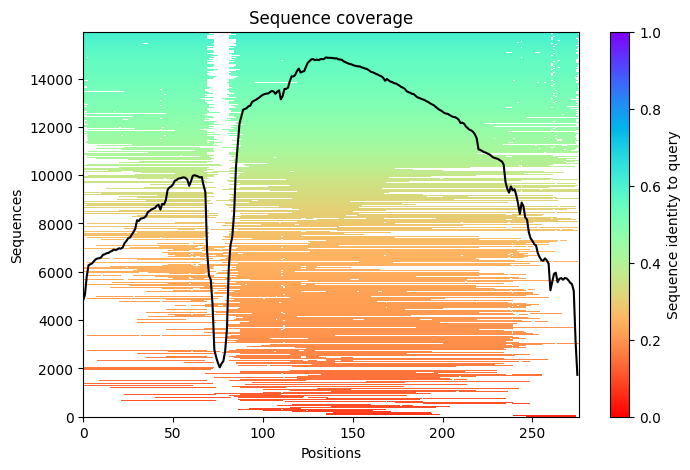

2026-06-17 23:06:16,582 Setting max_seq=512, max_extra_seq=5120
2026-06-17 23:07:23,797 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=81.4 pTM=0.731
2026-06-17 23:08:06,084 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=81.4 pTM=0.702 tol=0.594
2026-06-17 23:08:30,905 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=83.1 pTM=0.72 tol=0.271
2026-06-17 23:08:55,009 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=83.2 pTM=0.719 tol=0.167
2026-06-17 23:08:55,010 alphafold2_ptm_model_1_seed_000 took 139.7s (3 recycles)


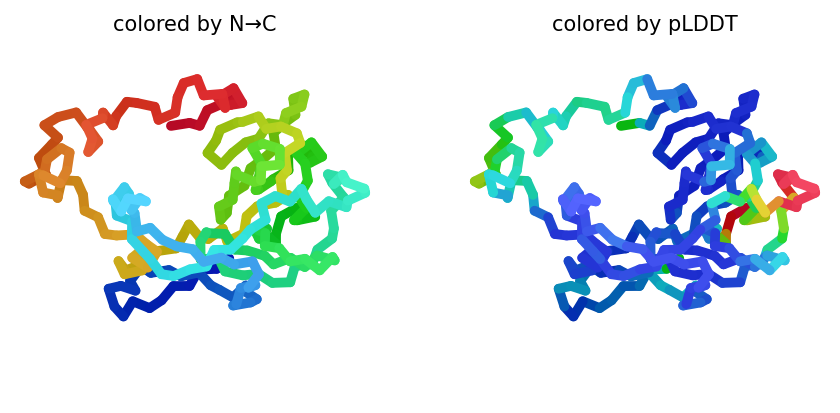

2026-06-17 23:09:19,423 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=77.6 pTM=0.598
2026-06-17 23:09:43,879 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=81.9 pTM=0.672 tol=0.581
2026-06-17 23:10:08,198 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=85.4 pTM=0.76 tol=0.387
2026-06-17 23:10:32,480 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=85.5 pTM=0.759 tol=0.204
2026-06-17 23:10:32,480 alphafold2_ptm_model_2_seed_000 took 97.3s (3 recycles)


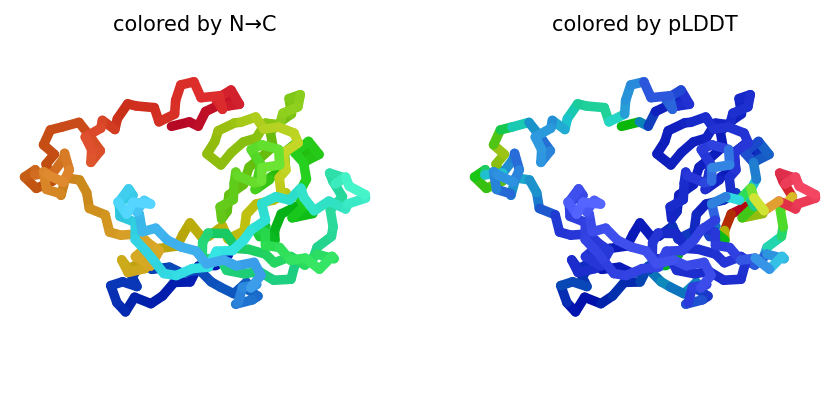

2026-06-17 23:10:56,919 alphafold2_ptm_model_3_seed_000 recycle=0 pLDDT=85.2 pTM=0.775
2026-06-17 23:11:21,228 alphafold2_ptm_model_3_seed_000 recycle=1 pLDDT=86.2 pTM=0.788 tol=0.544
2026-06-17 23:11:45,558 alphafold2_ptm_model_3_seed_000 recycle=2 pLDDT=86.6 pTM=0.791 tol=0.209
2026-06-17 23:12:09,811 alphafold2_ptm_model_3_seed_000 recycle=3 pLDDT=86.9 pTM=0.795 tol=0.1
2026-06-17 23:12:09,811 alphafold2_ptm_model_3_seed_000 took 97.2s (3 recycles)


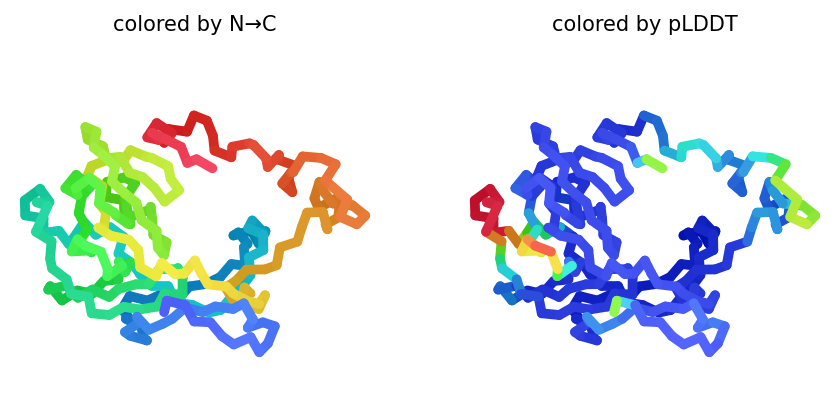

2026-06-17 23:12:34,249 alphafold2_ptm_model_4_seed_000 recycle=0 pLDDT=84.2 pTM=0.766
2026-06-17 23:12:58,518 alphafold2_ptm_model_4_seed_000 recycle=1 pLDDT=85.8 pTM=0.779 tol=0.722
2026-06-17 23:13:22,808 alphafold2_ptm_model_4_seed_000 recycle=2 pLDDT=86.1 pTM=0.778 tol=0.239
2026-06-17 23:13:47,086 alphafold2_ptm_model_4_seed_000 recycle=3 pLDDT=86.5 pTM=0.783 tol=0.34
2026-06-17 23:13:47,086 alphafold2_ptm_model_4_seed_000 took 97.1s (3 recycles)


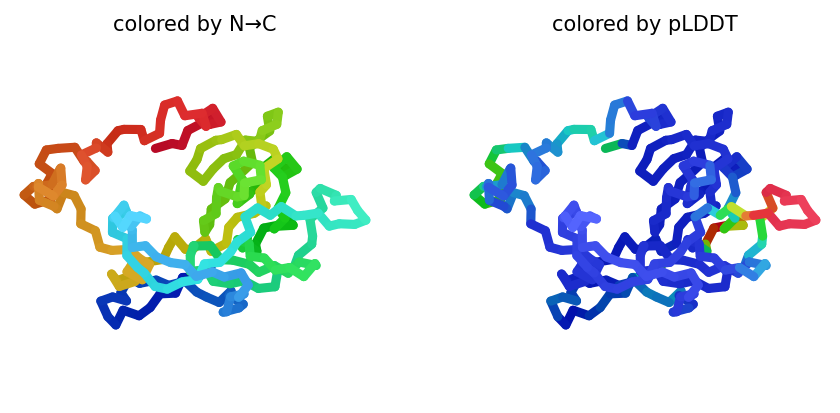

2026-06-17 23:14:11,584 alphafold2_ptm_model_5_seed_000 recycle=0 pLDDT=84.8 pTM=0.775
2026-06-17 23:14:35,922 alphafold2_ptm_model_5_seed_000 recycle=1 pLDDT=85.8 pTM=0.78 tol=1.02
2026-06-17 23:15:00,307 alphafold2_ptm_model_5_seed_000 recycle=2 pLDDT=85.8 pTM=0.772 tol=0.531
2026-06-17 23:15:24,706 alphafold2_ptm_model_5_seed_000 recycle=3 pLDDT=86.2 pTM=0.778 tol=0.566
2026-06-17 23:15:24,707 alphafold2_ptm_model_5_seed_000 took 97.5s (3 recycles)


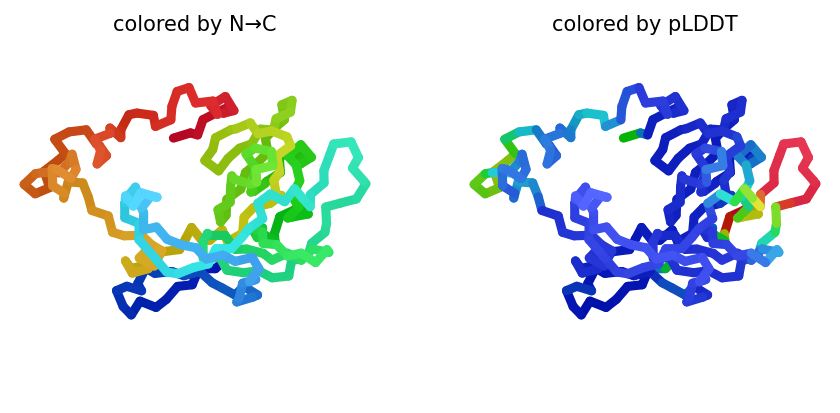

2026-06-17 23:15:24,876 reranking models by 'plddt' metric
2026-06-17 23:15:24,876 rank_001_alphafold2_ptm_model_3_seed_000 pLDDT=86.9 pTM=0.795
2026-06-17 23:15:24,876 rank_002_alphafold2_ptm_model_4_seed_000 pLDDT=86.5 pTM=0.783
2026-06-17 23:15:24,877 rank_003_alphafold2_ptm_model_5_seed_000 pLDDT=86.2 pTM=0.778
2026-06-17 23:15:24,877 rank_004_alphafold2_ptm_model_2_seed_000 pLDDT=85.5 pTM=0.759
2026-06-17 23:15:24,877 rank_005_alphafold2_ptm_model_1_seed_000 pLDDT=83.2 pTM=0.719
2026-06-17 23:15:26,081 Done


0

In [ ]:
# @title
display_images = False

import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2

import os
import numpy as np
try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt

# For some reason we need that to get pdbfixer to import
if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

def input_features_callback(input_features):
  if display_images:
    plot_msa_v2(input_features)
    plt.show()
    plt.close()

def prediction_callback(protein_obj, length,
                        prediction_result, input_features, mode):
  model_name, relaxed = mode
  if not relaxed:
    if display_images:
      fig = plot_protein(protein_obj, Ls=length, dpi=150)
      plt.show()
      plt.close()

result_dir = jobname
log_filename = os.path.join(jobname,"log.txt")
setup_logging(Path(log_filename))

queries, is_complex = get_queries(queries_path)
model_type = set_model_type(is_complex, model_type)

if "multimer" in model_type and max_msa is not None:
  use_cluster_profile = False
else:
  use_cluster_profile = True

download_alphafold_params(model_type, Path("."))
results = run(
    queries=queries,
    result_dir=result_dir,
    use_templates=use_templates,
    custom_template_path=custom_template_path,
    num_relax=num_relax,
    msa_mode=msa_mode,
    model_type=model_type,
    num_models=5,
    num_recycles=num_recycles,
    relax_max_iterations=relax_max_iterations,
    recycle_early_stop_tolerance=recycle_early_stop_tolerance,
    num_seeds=num_seeds,
    use_dropout=use_dropout,
    model_order=[1,2,3,4,5],
    is_complex=is_complex,
    data_dir=Path("."),
    keep_existing_results=False,
    rank_by="auto",
    pair_mode=pair_mode,
    pairing_strategy=pairing_strategy,
    stop_at_score=float(100),
    prediction_callback=prediction_callback,
    dpi=dpi,
    zip_results=False,
    save_all=save_all,
    max_msa=max_msa,
    use_cluster_profile=use_cluster_profile,
    input_features_callback=input_features_callback,
    save_recycles=save_recycles,
    user_agent="colabfold/google-colab-main",
    calc_extra_ptm=calc_extra_ptm,
)
results_zip = f"{jobname}.result.zip"
os.system(f"zip -r {results_zip} {jobname}")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

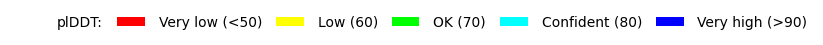

In [ ]:
# @title
import py3Dmol
import glob
import matplotlib.pyplot as plt
from colabfold.colabfold import plot_plddt_legend
from colabfold.colabfold import pymol_color_list, alphabet_list
rank_num = 1
color = "lDDT"
show_sidechains = False
show_mainchains = False

tag = results["rank"][0][rank_num - 1]
jobname_prefix = ".custom" if msa_mode == "custom" else ""
pdb_filename = f"{jobname}/{jobname}{jobname_prefix}_unrelaxed_{tag}.pdb"
pdb_file = glob.glob(pdb_filename)

def show_pdb(rank_num=1, show_sidechains=False, show_mainchains=False, color="lDDT"):
  model_name = f"rank_{rank_num}"
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
  view.addModel(open(pdb_file[0],'r').read(),'pdb')

  if color == "lDDT":
    view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':50,'max':90}}})
  elif color == "rainbow":
    view.setStyle({'cartoon': {'color':'spectrum'}})
  elif color == "chain":
    chains = len(queries[0][1]) + 1 if is_complex else 1
    for n,chain,color in zip(range(chains),alphabet_list,pymol_color_list):
       view.setStyle({'chain':chain},{'cartoon': {'color':color}})

  if show_sidechains:
    BB = ['C','O','N']
    view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
  if show_mainchains:
    BB = ['C','O','N','CA']
    view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

  view.zoomTo()
  return view

show_pdb(rank_num, show_sidechains, show_mainchains, color).show()
if color == "lDDT":
  plot_plddt_legend().show()


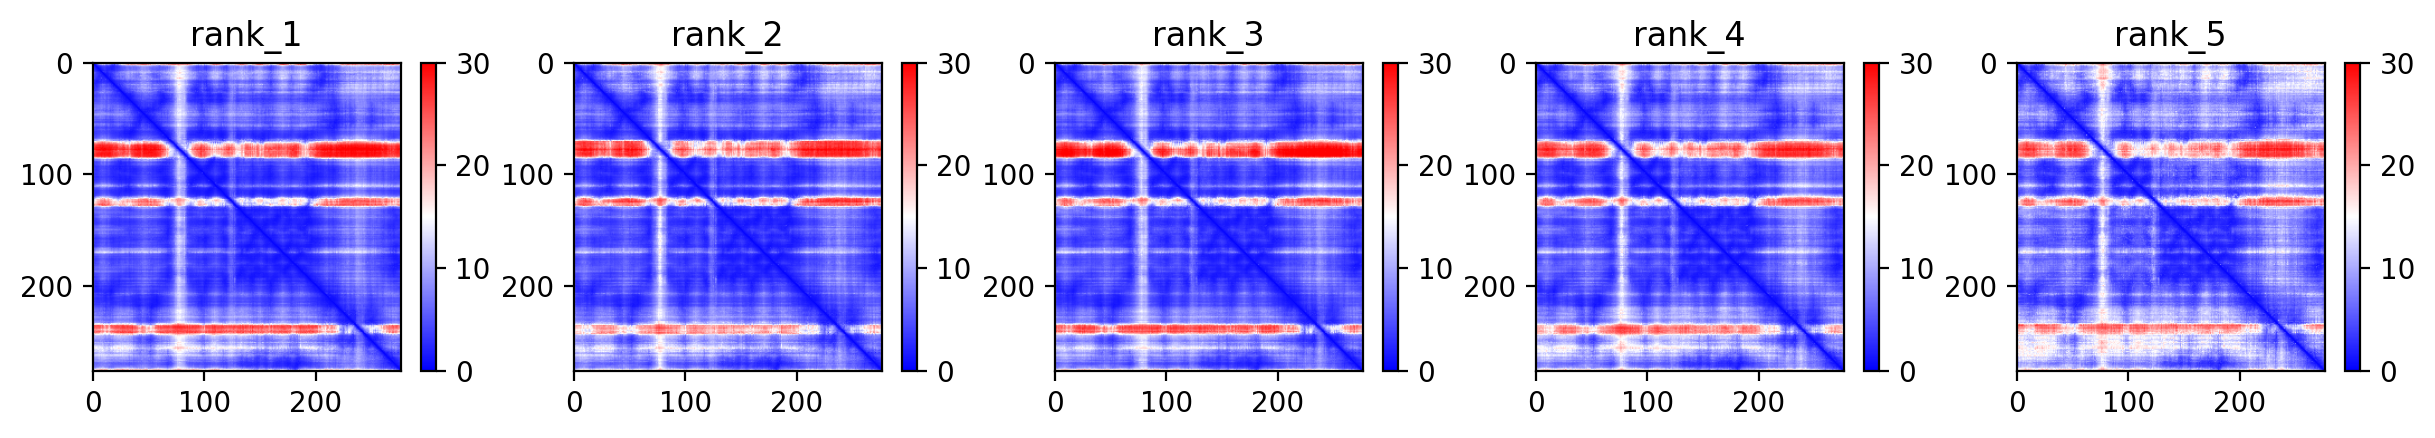
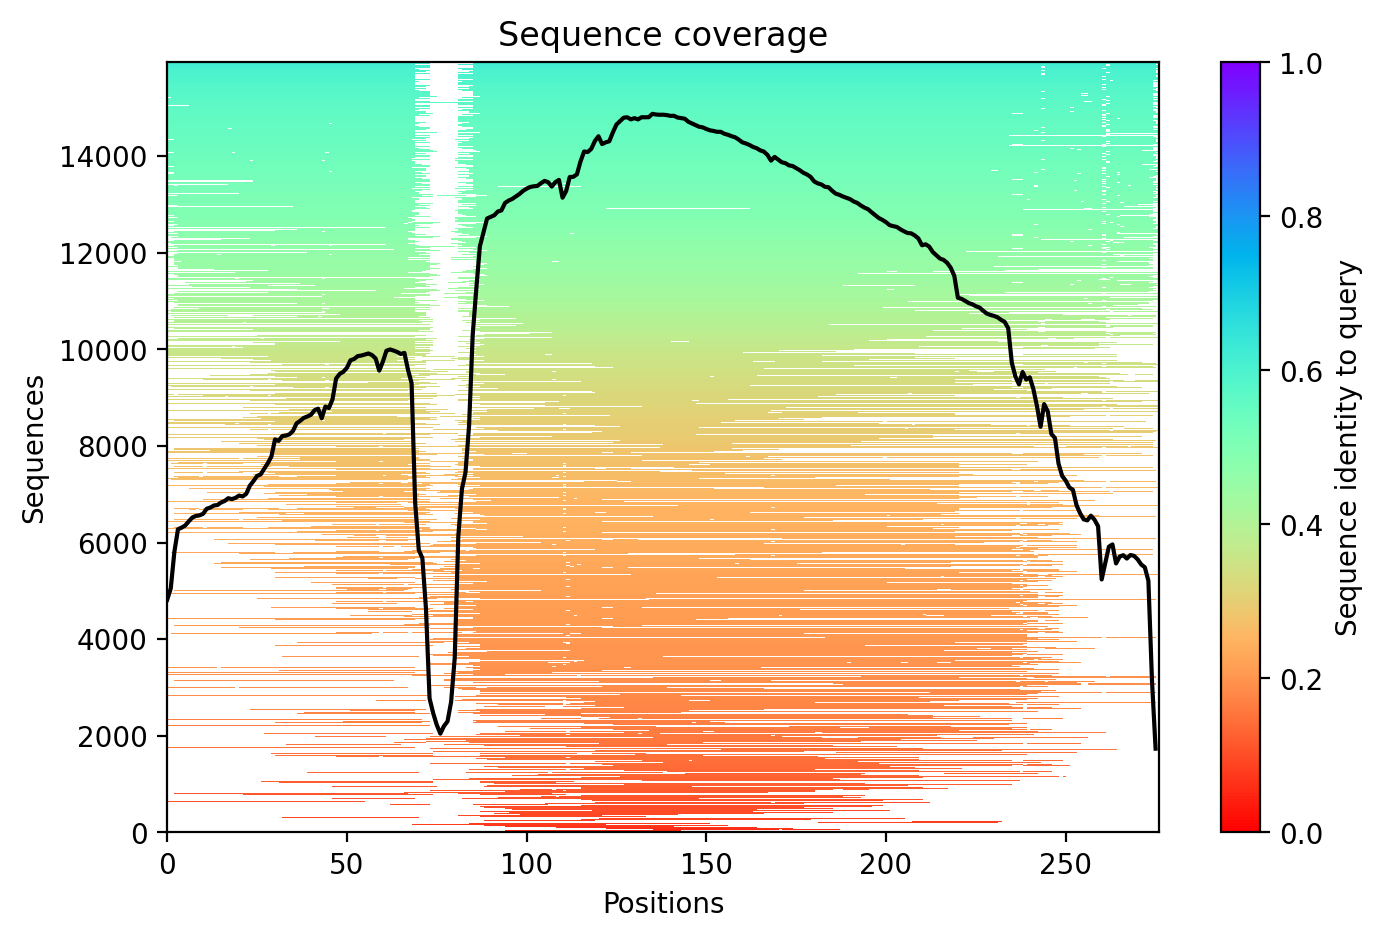
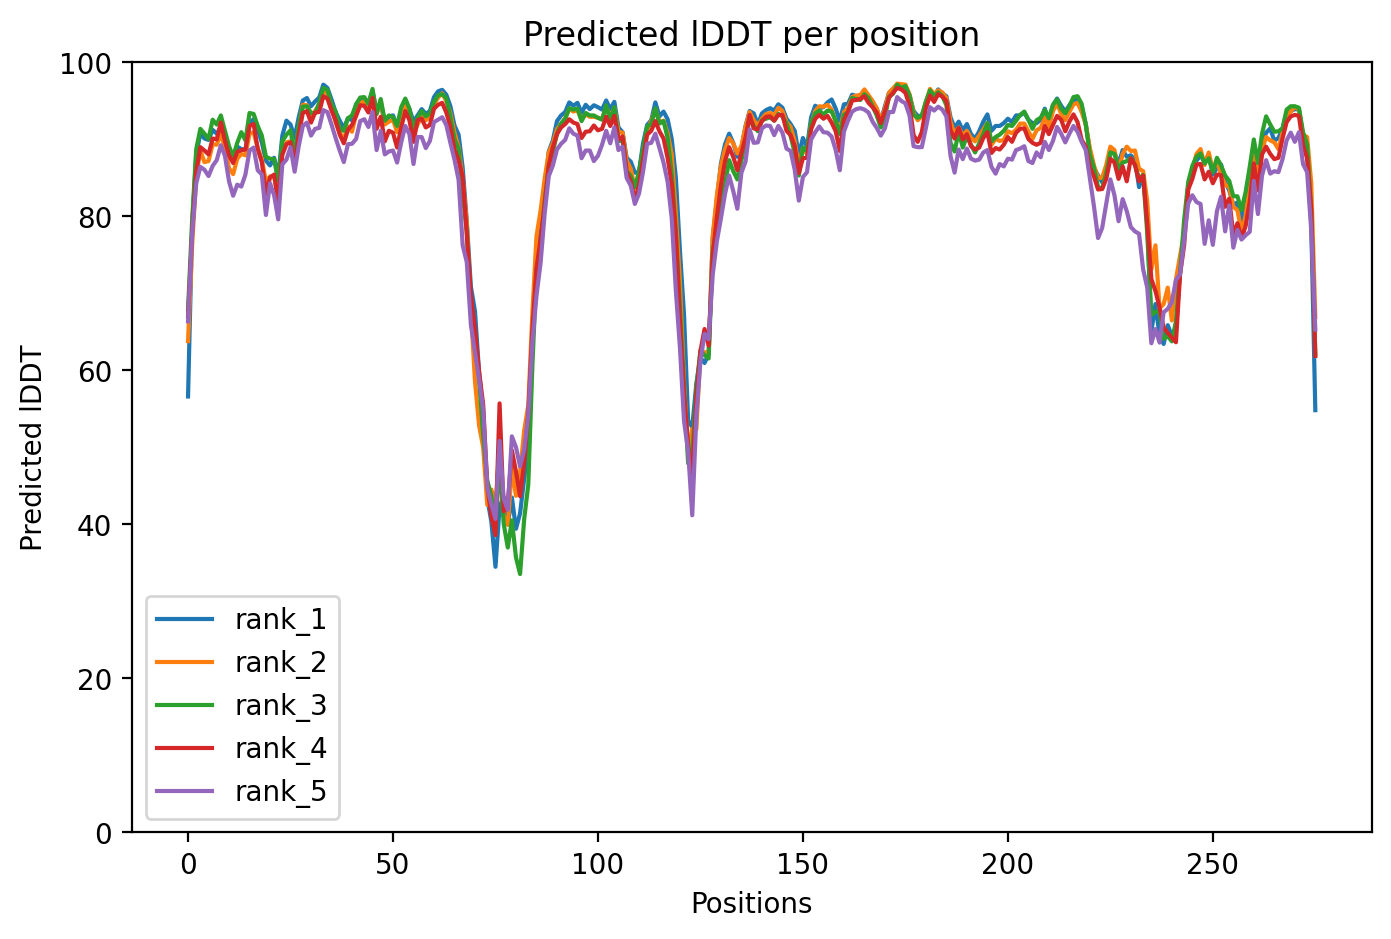

In [ ]:
# @title
from IPython.display import display, HTML
import base64
from html import escape

# see: https://stackoverflow.com/a/53688522
def image_to_data_url(filename):
  ext = filename.split('.')[-1]
  prefix = f'data:image/{ext};base64,'
  with open(filename, 'rb') as f:
    img = f.read()
  return prefix + base64.b64encode(img).decode('utf-8')

pae = ""
pae_file = os.path.join(jobname,f"{jobname}{jobname_prefix}_pae.png")
if os.path.isfile(pae_file):
    pae = image_to_data_url(pae_file)
cov = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_coverage.png"))
plddt = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_plddt.png"))
display(HTML(f"""
<style>
  img {{
    float:left;
  }}
  .full {{
    max-width:100%;
  }}
  .half {{
    max-width:50%;
  }}
  @media (max-width:640px) {{
    .half {{
      max-width:100%;
    }}
  }}
</style>
<div style="max-width:90%; padding:2em;">
  <h1>Plots for {escape(jobname)}</h1>
  { '<!--' if pae == '' else '' }<img src="{pae}" class="full" />{ '-->' if pae == '' else '' }
  <img src="{cov}" class="half" />
  <img src="{plddt}" class="half" />
</div>
"""))

# 3. Ping server for PDB downloads

In [ ]:
import requests
from urllib.parse import quote
import pandas as pd
import os
import shutil

```UniProt()``` class for data requests, importing and processing
```makeProteinDataframe()``` class for obtaining dataframe table of protein accession information

In [ ]:
# @title
class UniProt:
  def __init__(self):
    self.proteome_cache = {}

  def fetch_pdb(self, accession, save_directory,fileName):
    """
    Download AlphaFold PDB for a UniProt accession.

    Returns
    -------
    str or None
        Path to downloaded pdb file.
    """

    os.makedirs(save_directory, exist_ok=True)

    pdb_url = (
        f"https://alphafold.ebi.ac.uk/files/"
        f"AF-{accession}-F1-model_v6.pdb"
    )

    outfile = os.path.join(
        save_directory,
        f"{fileName}.pdb"
    )

    r = requests.get(pdb_url)

    if r.status_code != 200:
        print(f"AlphaFold PDB not found for {accession} {pdb_url}")
        return None

    with open(outfile, "wb") as f:
        f.write(r.content)

    return outfile

  def zip_pdb_folder(self, folder_path):
    """
    Creates

    folder.zip

    beside folder.
    """

    zip_file = shutil.make_archive(
        folder_path,
        "zip",
        folder_path
    )

    print(f"Created {zip_file}")

    return zip_file

  def sequence_from_pdb(self,pdb_file):
    aa3to1 = {
        'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C',
        'GLN':'Q','GLU':'E','GLY':'G','HIS':'H','ILE':'I',
        'LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P',
        'SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V'
    }

    seq = []

    with open(pdb_file) as f:
        for line in f:
            if line.startswith("SEQRES"):
                residues = line.split()[4:]
                seq.extend(aa3to1[r] for r in residues)

    sequence = "".join(seq)

    return sequence

  def fetch_all_pdb_from_csv(
        self,
        csv_file,
        pdb_directory
   ):
    """
    Parameters
    ----------
    csv_file
        Existing csv

    pdb_directory
        Folder to store pdb files

    Produces
    --------
    copy csv

    Adds column

        PDBFile

    Only downloads structures whose
    sequence matches fullFasta.
    """

    os.makedirs(
        pdb_directory,
        exist_ok=True
    )

    df = pd.read_csv(csv_file)

    if "PDBFile" not in df.columns:
        df["PDBFile"] = ""
        df["PDBSequenceMatch"] = False
        df["PDBLength"] = 0

    for i, row in df.iterrows():

        accession = row["UniprotAccession"]

        if pd.isna(accession) or accession == "":
            continue

        PDBfileName = row['fullFastaFileSeqName']

        if PDBfileName is None:
            print(f"No PDB file name for {accession} {row['trimmedFileSeqName']}")
            continue

        print(PDBfileName)

        if type(PDBfileName) != str:
          print(f"{PDBfileName} not str")
          continue

        if PDBfileName=='nan':
          continue

        PDBfileName = PDBfileName.replace('/','[forward_slash_character]')

        pdb_file = self.fetch_pdb(accession,pdb_directory,PDBfileName)

        if pdb_file is None:
            continue

        pdb_sequence = self.sequence_from_pdb(pdb_file)

        fasta_sequence = row["fullFasta"]

        if pdb_sequence != fasta_sequence:

            print(
                f"Sequence mismatch "
                f"{accession}"
            )

            df.at[i, "PDBSequenceMatch"] = False
            # os.remove(pdb_file)

        df.at[i, "PDBSequenceMatch"] = True
        df.at[i, "PDBLength"] = len(pdb_sequence)
        df.at[i, "PDBFile"] = os.path.basename(pdb_file)

    copy_name = (
        os.path.splitext(csv_file)[0]
        + "_withPDB.csv"
    )

    df.to_csv(
        copy_name,
        index=False
    )

    print(f"Saved {copy_name}")

    zip_file = self.zip_pdb_folder(
        pdb_directory
    )

    print(zip_file)

    return copy_name, zip_file

  def get_proteome(self, taxon_id, gene_name="", protein_name=""):
    """
    Retrieve candidate UniProt entries for a protein from a given organism.

    Query:
        organism_id:<taxon> AND (gene:<gene> OR protein:<protein>)

    Returns
    -------
    list
        List of matching UniProt entries.
    """

    if taxon_id in self.proteome_cache:
      return self.proteome_cache[taxon_id]

    query_parts = [f"organism_id:{taxon_id}"]

    search_terms = []

    if gene_name:
        search_terms.append(f"gene:{gene_name}")

    if protein_name:
        search_terms.append(f'protein_name:"{protein_name}"')

    if search_terms:
        query_parts.append("(" + " OR ".join(search_terms) + ")")

    query = " AND ".join(query_parts)

    fields = (
        "accession,"
        "gene_names,"
        "protein_name,"
        "organism_name,"
        "reviewed,"
        "sequence"
    )

    url = (
        "https://rest.uniprot.org/uniprotkb/search"
        f"?query={query}"
        f"&fields={fields}"
        "&format=json"
        "&size=20"
    )

    print(f"Query: {query}")

    r = requests.get(url)

    if not self.requestStatus(r):
        print(f"\n========== Failed retrieving entries for taxon {taxon_id} ==========\n")
        return []

    data = r.json()

    results = data.get("results", [])
    if not results:
        print(f"\n========== No results found for taxon {taxon_id} ==========\n")

    self.proteome_cache[taxon_id] = results
    return results

  def choose_best_match(
        self,
        entries,
        gene_name,
        protein_name,
        reference_sequence=None
    ):
    """
    Select the best UniProt entry.

    Priority

    1. Exact sequence match
    2. Reviewed entry
    3. Exact gene match
    4. Protein name contains keyword
    5. Longest sequence
    """

    if len(entries) == 0:
        return None

    scored = []

    # {'entryType': 'UniProtKB reviewed (Swiss-Prot)',
    # 'primaryAccession': 'Q72JU9',
    # 'organism': {'scientificName': 'Thermus thermophilus (strain ATCC BAA-163 / DSM 7039 / HB27)',
    #              'taxonId': 262724,
    #              'lineage': ['Bacteria', 'Thermotogati', 'Deinococcota', 'Deinococci', 'Thermales', 'Thermaceae', 'Thermus']
    #             }

    for entry in entries:

        accession = entry["primaryAccession"]

        sequence = entry["sequence"]["value"]

        genes = []

        for g in entry.get("genes", []):

            if "geneName" in g:
                genes.append(g["geneName"]["value"].lower())

        protein = ""

        protein_desc = entry.get("proteinDescription", {})

        if "recommendedName" in protein_desc:

          protein = (
              protein_desc["recommendedName"]
                          .get("fullName", {})
                          .get("value", "")
          )

        elif "submissionNames" in protein_desc:

          protein = (
              protein_desc["submissionNames"][0]
                          .get("fullName", {})
                          .get("value", "")
          )

        protein = protein.lower()

        # protein = (
        #     entry.get("proteinDescription", {})
        #          .get("recommendedName", {})
        #          .get("fullName", {})
        #          .get("value", "")
        #          .lower()
        # )

        reviewed = (
            "reviewed"
            in entry.get("entryType", "").lower()
        )

        score = 0

        if reference_sequence is not None:

            if sequence == reference_sequence:
                score += 1000

        if reviewed:
            score += 100

        if gene_name:

            if gene_name.lower() in genes:
                score += 50

        if protein_name:

            keywords = [
              protein_name.lower(),
              f"ribosomal protein {protein_name.lower()}",
              f"protein {protein_name.lower()}"
          ]

            for keyword in keywords:

                if keyword in protein:
                    score += 25
                    break

        score += len(sequence) / 1000

        scored.append(
            (
                score,
                accession,
                sequence,
                entry
            )
        )

    scored.sort(reverse=True)

    return scored[0][3]

  def get_best_match_from_proteome(
        self,
        taxon_id,
        gene_name,
        protein_name="",
        reference_sequence=None
    ):
    """
    Returns the best matching UniProt entry.

    Returns
    -------
    dict or None

    {
        "accession": ...,
        "species": ...,
        "sequence": ...
    }
    """

    entries = self.get_proteome(taxon_id=taxon_id,
                                gene_name=gene_name,
                                protein_name=protein_name)

    if len(entries) == 0:
        return None

    best = self.choose_best_match(
        entries,
        gene_name,
        protein_name,
        reference_sequence
    )

    if best is None:
        return None

    accession = best["primaryAccession"]

    species = best["organism"]["scientificName"]

    sequence = best["sequence"]["value"]

    if reference_sequence is not None:

      if sequence != reference_sequence:

          print(
              f"\nSequence mismatch "
              f"accession {accession} "
              f"species{species}"
              f"taxon {taxon_id}\n"
          )
          return None

    # if reference_sequence is not None and sequence != reference_sequence:
    #     print(f"WARNING: Sequence mismatch for taxon {taxon_id}")
    #     return None

    return {
        "accession": accession,
        "species": species,
        "sequence": sequence
    }

  def get_best_accession_from_proteome(
        self,
        taxon_id,
        gene_name,
        protein_name="",
        reference_sequence=None
        ):

    entries = self.get_proteome(taxon_id)

    if len(entries) == 0:
        return None

    best = self.choose_best_match(
        entries,
        gene_name,
        protein_name,
        reference_sequence
    )

    if best is None:
        return None

    return best["primaryAccession"]

  def requestStatus(self,req):
    if req.status_code == 200:
      return True
    return False

  def get_uniprot_sequence_and_name(self,accession):
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.json"

    r = requests.get(url)
    if not self.requestStatus(r):
      print(f"==========Request failed for {accession}==========")
      return None
    # r.raise_for_status()

    data = r.json()

    # print(data["organism"]["scientificName"])
    # print('_'.join(data["organism"]["scientificName"].split(' ')[:2]))

    seq = data["sequence"]["value"]
    seq_name = '_'.join(data["organism"]["scientificName"].split(' ')[:2])

    # print(f">{accession}")
    # print(seq)
    # print(f"Length = {len(seq)}")

    return seq_name, seq

  def get_uniprot_sequence_name(self,accession):
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.json"

    r = requests.get(url)
    if not self.requestStatus(r):
      print(f"==========Request failed for {accession}")
      return None
    # r.raise_for_status()

    data = r.json()

    return data["organism"]["scientificName"]

  def get_uniprot_accession(self, taxon_id=None, gene_name=None, protein_name=None):
    """
    Retrieve the first matching UniProt accession.

    Parameters
    ----------
    taxon_id : str or int, optional
        NCBI taxonomy ID.
    gene_name : str, optional
        Gene symbol (e.g. 'rplX').
    protein_name : str, optional
        Protein name (e.g. '50S ribosomal protein uL24').

    Returns
    -------
    str or None
        UniProt accession if found, else None.
    """

    query_parts = []

    if taxon_id is not None:
        query_parts.append(f"organism_id:{taxon_id}")

    if gene_name:
        query_parts.append(f"gene:{gene_name}")

    if protein_name:
        # Quote the protein name so spaces are handled correctly
        query_parts.append(f'protein_name:"{protein_name}"')

    if not query_parts:
        raise ValueError(
            "At least one of taxon_id, gene_name, or protein_name must be provided."
        )

    query = " AND ".join(query_parts)

    url = (
        "https://rest.uniprot.org/uniprotkb/search"
        f"?query={query}"
        "&fields=accession,protein_name,gene_names,organism_name"
        "&format=json"
        "&size=5"
    )

    r = requests.get(url)

    if not self.requestStatus(r):
        print(f"==========Request failed")
        return None

    data = r.json()

    if len(data["results"]) == 0:
        print("==========No results found")
        return None

    # Print all matches for debugging
    # for i, result in enumerate(data["results"], start=1):
    #     accession = result["primaryAccession"]

    #     protein = result.get("proteinDescription", {}) \
    #                     .get("recommendedName", {}) \
    #                     .get("fullName", {}) \
    #                     .get("value", "Unknown")

    #     genes = ", ".join(
    #         g["value"] for g in result.get("genes", [])
    #         if "value" in g
    #     )

    #     organism = result.get("organism", {}).get("scientificName", "Unknown")

    #     print(f"{i}. {accession}")
    #     print(f"   Protein : {protein}")
    #     print(f"   Gene    : {genes}")
    #     print(f"   Organism: {organism}")
    #     print()

    return data["results"][0]["primaryAccession"]

  def old_get_uniprot_accession(self,taxon_id,gene_name):
    url = (
        "https://rest.uniprot.org/uniprotkb/search"
        f"?query=organism_id:{taxon_id}+AND+gene:{gene_name}"
        "&fields=accession"
        "&format=json"
        "&size=1"
    )

    r = requests.get(url)
    if not self.requestStatus(r):
      print(f"==========Request failed for {taxon_id}")
      return None
    # r.raise_for_status()

    data = r.json()

    if len(data["results"]) == 0:
      print(f"==========No results for {taxon_id}")
      return None

    return data["results"][0]["primaryAccession"]

# seq = get_uniprot_sequence("Q02RL5")
class makeProteinDataframe:
  def __init__(self,domain,protein,trimmed_fasta_file,full_seq_fasta_file,gene_name, protein_name, available_csv=""):
    self.CSV_File = available_csv
    self.protein_name = protein_name
    self.domain = domain
    self.protein = protein
    self.trimmed_fasta_file = trimmed_fasta_file
    self.full_seq_fasta_file = full_seq_fasta_file
    self.gene_name = gene_name
    self.df = pd.DataFrame()
    self.df_dict = {"protein_domain":[],"protein_name":[],"taxonID":[],"UniprotAccession":[],"specieName":[],"fullFasta":[],"seqBoundaries":[],"trimmedSequence":[],"trimmedFileSeqName":[],"fullFastaFileSeqName":[]}

  def readFastaByTaxon(self, fasta_file):
    """
    Returns

    {
        taxonID : sequence
    }
    """

    seq_dict = {}

    sequence = []

    taxon = None

    with open(fasta_file) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):

                if taxon is not None:

                    seq_dict[taxon] = "".join(sequence)

                header = line[1:]

                taxon = self.getTaxonID(header)

                sequence = []

            else:

                sequence.append(line)

        if taxon is not None:

            seq_dict[taxon] = "".join(sequence)

    return seq_dict

  def readFasttoHashmap(self,fasta_file):
    """protein.fa -> {name:seq}"""
    name_seqs={}
    contig,name=[],""
    for line in open(fasta_file):
      line = line.strip()
      if not line:
        continue
      if line[0] == '>':
        if contig:
          name_seqs[name] = ''.join(contig)
          contig=[]
        name = line[1:]
        if '/' in name:
          name = name.replace('/','[forward_slash_character]')
        name_seqs[name] = ""
      else:
        contig.append(line)
    name_seqs[name] = ''.join(contig)
    return name_seqs

  def getTaxonID(self,seq_name):
    """seq_name is SH3_bL19_208963_name_boundaries"""
    return seq_name.split('_')[2]

  def sameNameandSequence(self,seq_dict,search_name):
    "Bacteria_P_aeruginosa_someIdentifiers:[FastaSequence] -> name:seqence"
    if not search_name:
      return False
    for seq_name in seq_dict:
      if search_name in seq_name:
        return True
    return False

  def givenCSV_main(self,csv_name):
    df = pd.read_csv(self.CSV_File)
    full_seq_fasta_dict = self.readFasttoHashmap(self.full_seq_fasta_file)

    for row in df.itertuples():
      self.df_dict["protein_domain"].append(self.domain)
      self.df_dict["protein_name"].append(self.protein)
      self.df_dict["taxonID"].append(row.taxonID)

      # assuming all rows have uniprot accession id
      accessionId, uniprotSeqName, specieName, fullFasta = row.UniprotAccession, row.specieName, row.specieName, row.fullFasta
      if row.UniprotAccession == '':
        print(f"{row.taxonID} does not have accession Id")
      else:
        accessionId = row.UniprotAccession
        self.df_dict["UniprotAccession"].append(accessionId)

        # assuming error is with not obtaining specie name and fasta sequence
        specieName, fullFasta = UniProt().get_uniprot_sequence_and_name(accessionId)
        if not self.sameNameandSequence(full_seq_fasta_dict,specieName):
          print(f"{self.protein} sequence for {specieName} obtained from Uniprot not same as that in the original file")

      self.df_dict["specieName"].append(specieName)
      self.df_dict["fullFasta"].append(fullFasta)
      self.df_dict["seqBoundaries"].append(row.seqBoundaries)
      self.df_dict["trimmedSequence"].append(row.trimmedSequence)

      counter += 1
      if counter % 20 == 0:
        print(f"{counter} sequences done")

    self.df = pd.DataFrame(self.df_dict)
    return self.df.to_csv(f"{csv_name}.csv",index=False)


  def main(self,csv_name):
    if self.CSV_File:
      self.givenCSV_main(csv_name)
      return

    uniprot = UniProt()

    trimmed_fasta_dict = self.readFasttoHashmap(self.trimmed_fasta_file)
    fullSeq_fasta_name_and_seq = self.readFasttoHashmap(self.full_seq_fasta_file)

    # full_seq_fasta_dict = self.readFastaByTaxon(
    # self.full_seq_fasta_file
    # )

    counter = 0
    for seq_name in trimmed_fasta_dict:
      print(seq_name,end=" ")
      if self.getTaxonID(seq_name) == 'ancesroot':
        print("ancesroot skipped")
        continue

      # storage
      self.df_dict["protein_domain"].append(self.domain)
      self.df_dict["protein_name"].append(self.protein)

      # search
      taxon = self.getTaxonID(seq_name)

      # storage
      self.df_dict["taxonID"].append(taxon)

      print("taxonID=",self.df_dict["taxonID"][-1])

      # search
      # reference_sequence = full_seq_fasta_dict.get(taxon)

      match = uniprot.get_best_match_from_proteome(
        taxon_id=taxon,
        gene_name=self.gene_name,
        protein_name=self.protein_name,
        reference_sequence=None#reference_sequence
        )

      # storage
      fullFasta_seq_name = "" # default value for full fasta seq name

      if match is None:

          print(f"\n=========={seq_name}: No matching UniProt entry ==========\n")

          self.df_dict["UniprotAccession"].append("")
          self.df_dict["specieName"].append("")
          self.df_dict["fullFasta"].append("")

      else:

          self.df_dict["UniprotAccession"].append(
              match["accession"]
          )

          self.df_dict["specieName"].append(
              "_".join(match["species"].split()[:2])
          )

          self.df_dict["fullFasta"].append(
              match["sequence"]
          )

          specieNameSearch = "_".join(match["species"].split()[:2]).lower()
          alternateSpecieNameSearch = match["species"].split()[:2][0].lower()

          # search with name
          for fasta_name in fullSeq_fasta_name_and_seq:
            lowerCase_fasta_name = fasta_name.lower()
            if specieNameSearch in lowerCase_fasta_name or alternateSpecieNameSearch in lowerCase_fasta_name:
              fullFasta_seq_name = fasta_name
              break

          # search with sequence
          for fasta_name in fullSeq_fasta_name_and_seq:
            if fullSeq_fasta_name_and_seq[fasta_name].replace('-','') == match["sequence"]:
              fullFasta_seq_name = fasta_name
              break

      seqBoundaries = seq_name.split('_')[-1]
      self.df_dict["seqBoundaries"].append(seqBoundaries)

      trimmedSequence = trimmed_fasta_dict[seq_name]
      self.df_dict["trimmedSequence"].append(trimmedSequence)

      self.df_dict["trimmedFileSeqName"].append(seq_name)
      self.df_dict["fullFastaFileSeqName"].append(fullFasta_seq_name)

      # # search

      # specieName, fullFasta = "", ""
      # if accessionId:
      #   specieName, fullFasta = UniProt().get_uniprot_sequence_and_name(accessionId)
      #   # uniprotSeqName = UniProt().get_uniprot_sequence_name(accessionId)
      #   # specieName, fullFasta = self.getNameandSequence(full_seq_fasta_dict, uniprotSeqName)
      #   if not self.sameNameandSequence(full_seq_fasta_dict,specieName):
      #     print(f"\n\n{self.protein} sequence for {specieName} obtained from Uniprot not same as that in the original file\n\n")
      # else:
      #   print(f"\n\n{seq_name} no accession ID obtained \n\n")

      # self.df_dict["specieName"].append(specieName)
      # self.df_dict["fullFasta"].append(fullFasta)

      counter += 1
      if counter % 20 == 0:
        print(f"\n\n\n{counter} sequences done\n\n\n")

    self.df = pd.DataFrame(self.df_dict)
    return self.df.to_csv(f"{csv_name}.csv",index=False)

#### get CSV

In [ ]:
#@title uL24 protein
uL24_df = makeProteinDataframe(domain="SH3",protein="uL24",
                               trimmed_fasta_file="SH3_uL24_trimmed.fa",
                               full_seq_fasta_file="SH3_uL24.fas",
                               gene_name='rplX',
                               protein_name='L24',
                               available_csv="")
uL24_df.main("SH3_uL24") #don't add .csv

In [ ]:
#@title bL19 protein
bL19_df = makeProteinDataframe(domain="SH3",protein="bL19",
                               trimmed_fasta_file="SH3_bL19_trimmed.fa",
                               full_seq_fasta_file="SH3_bL19.fas",
                               gene_name='rplS',
                               protein_name="L19",
                               available_csv="")
bL19_df.main("SH3_bL19") #don't add .csv

SH3_bL19_262724_THET2_22-31,44-53,59-78 taxonID= 262724
Query: organism_id:262724 AND (gene:rplS OR protein_name:"L19")
SH3_bL19_100226_STRCO_20-29,42-51,57-76 taxonID= 100226
Query: organism_id:100226 AND (gene:rplS OR protein_name:"L19")
SH3_bL19_1148_SYNYG_24-33,46-55,61-80 taxonID= 1148
Query: organism_id:1148 AND (gene:rplS OR protein_name:"L19")

========== No results found for taxon 1148 ==========


==========SH3_bL19_1148_SYNYG_24-33,46-55,61-80: No matching UniProt entry ==========

SH3_bL19_156889_MAGMM_20-29,42-51,57-76 taxonID= 156889
Query: organism_id:156889 AND (gene:rplS OR protein_name:"L19")
SH3_bL19_159087_DECAR_22-31,44-53,59-78 taxonID= 159087
Query: organism_id:159087 AND (gene:rplS OR protein_name:"L19")
SH3_bL19_165597_CROWT_22-31,44-53,59-78 taxonID= 165597
Query: organism_id:165597 AND (gene:rplS OR protein_name:"L19")
SH3_bL19_169963_LISMO_20-29,42-51,57-76 taxonID= 169963
Query: organism_id:169963 AND (gene:rplS OR protein_name:"L19")
SH3_bL19_171101_STRR6_

#### get PDBs

In [ ]:
uniprot = UniProt()

uniprot.fetch_all_pdb_from_csv(
    csv_file="SH3_uL24.csv",
    pdb_directory="SH3_uL24_PDBs"
)

MRVKMHVKKGDTVLVASGKYKGRVGKVKEVLPKKYAVIVEGVNIVKKAVRVSPKYPQGGFIEKEAPLHASKVRPICPACGKPTRVRKKFLENGKKIRVCAKCGGALDTEE
MKIKKGDLVQVITGKDKGKQGKVIAAFPREDRVLVEGVNRVKKHTKAGPTARGSQAGGIVTTEAPIHVSNVQLVVEKDGNKVVTRVGYRFDDEGNKVRVAKRTGEDI
MAEHKSDFSTDLKKGDTVIVVAGKDKGKQGQILQVLGKKSSVLVEKVNMIKRHTKPAQNREGGIVEKEAPIHISNVMIVDPATGKATRIKKKNLEDGRKVRVAAGSGEVLDK
MMEKIRKGDEIVVITGKDKGKRGTVLRRVDDEHVLVEGVNRAKKHVKPNPVKGVAGGIVDKDMPIHISNVALFNPATKKADRVGFKALDDGRKVRVFKSNGELVNA
MSKKKSPPKRHKMHVKKGDTIQVISGRDKGKVGEITQTLPKTGQVVVKGVNVRTKHVKPQQEGESGQISTFEAPIHSSNVMLYSTKEQVASRISYTFTEEGRKVRMLKKTGEIID
MHVKKGDKVKVITGKDKGKSGKVLAAFPKKDRVLIEGINMVKKHTKPSNVNPQGGILNVEAPIHVSNVMLIDPKTGEPTRVGYEVKGDKKVRVAKKSGEVIDK
MFVKKGDKVRVIAGKDKGTEAVVLTALPKVNKVIVEGVNIVKKHQRPTNELPQGGIIEKEAAIHVSNVQVLDKNGVAGRVGYKFVDGKKVRYNKKSGEVLD
MQKIRKGDNVVVLTGKDKGRTGEVIQVMPKEDRAVVRGVNMVKRHQRQTQAQEAGIINKEASLHISNIAIVDKDGKPTRVGFSVVDGKKVRVAKRSGEVIDG
MAKPKIKFVPDSLHVKTGDIVYVISGKDKKMTGKVLKVFPKKGKIIVEGINIVTKHLKPSQVNPQGGVVQKEAAIFSSKVMLFDEKTKSPTRVGYEVRDGKKVRISKKSGEII
MANRIKKGDQVVINTGKDKGKQ

('SH3_uL24_withPDB.csv', '/content/SH3_uL24_PDBs.zip')

In [ ]:
uniprot = UniProt()

uniprot.fetch_all_pdb_from_csv(
    csv_file="SH3_bL19.csv",
    pdb_directory="SH3_bL19_PDBs"
)

Bacteria_Thermus_thermophilus_HB27_
Bacteria_Streptomyces_coelicolor_A3(2)_
Bacteria_Magnetococcus_sp._MC-1_
Bacteria_Dechloromonas_aromatica_RCB_
Bacteria_Crocosphaera_watsonii_WH_8501_
Bacteria_Listeria_monocytogenes_EGD-e_
Bacteria_Streptococcus_pneumoniae_R6_
Bacteria_Agrobacterium_tumefaciens_str._C58_
Bacteria_Fusobacterium_nucleatum_subsp._nucleatum_ATCC_25586_
Bacteria_Xanthomonas_axonopodis_pv._citri_str._306_
Bacteria_Chlorobium_tepidum_TLS_
Bacteria_Thermosynechococcus_elongatus_BP-1_
Bacteria_Tropheryma_whipplei_str._Twist_
Bacteria_Blochmannia_floridanus
Bacteria_Pseudomonas_aeruginosa_UCBPP-PA14_
Bacteria_Shewanella_oneidensis_MR-1_
Bacteria_Oceanobacillus_iheyensis_HTE831_
Bacteria_Bradyrhizobium_japonicum_USDA_110_
Bacteria_Bacteroides_thetaiotaomicron_VPI-5482_
Bacteria_Coxiella_burnetii_RSA_493_
Bacteria_Chlamydophila_caviae_GPIC_
Bacteria_Nitrosomonas_europaea_ATCC_19718_
Bacteria_Helicobacter_hepaticus_ATCC_51449_
Bacteria_Geobacillus_kaustophilus_HTA426_
nan
nan no

('SH3_bL19_withPDB.csv', '/content/SH3_bL19_PDBs.zip')

#### comments and notes section

In [ ]:
# one file which has {protein_domain}_{protein_name}_{taxonID}_{someShortForm}_{seqBoundaries} and trimmed Sequence
# one file which has {specie}_{name_of_the_species}_{someIdentifiers} and full fasta sequence
# make one big dataframe columns=[protein_domain,protein_name,taxonID,getUniprotID,fetched specie,fetched specie name, get specie name full fasta sequence,seqBoundaries,trimmedSequence]
# all proteins except that named ancesroot
# for specific protein (and protein domain) get the PDB for all uniprot ID, check the sequence wth given sequence and trimmed sequence, store if this is not a match, and store in zip file
# print those PDB files that were not found
# maintain a dictionary with key as uniprot and value as 1 or 0 as found pdb or not found pdb, assess the links for them

In [ ]:
# uL24
# B8H4E5 - Caulobacter vibrisodis is fixed

In [ ]:
# 16 Jul
# What changes can I make?
## Query for the organism, not just gene name and taxonID - cascade choice
## checking if the name obtained is there in the sequence names list, don't do that check with seqeunce comparisons
## specie names may not entirely be standardized, include a lowercase
## Don't make too many requests --> query once and cache the results
## sngle indexing key for UniProt sequence and fasta sequence --> easier comparison
## SAVE ORIGINAL FILE NAMES ALSO